In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from utils.utils import connection

ModuleNotFoundError: No module named 'utils'

In [ ]:
companies = pd.read_sql("SELECT * FROM companies", connection())

In [ ]:
companies

,id,ticker,name,figi,currency,lot,min_price_increment,sector,created_at,updated_at
0,1,SBER,ПАО Сбербанк,BBG004730N88,rub,1,0.010,financial,2025-11-13 08:17:24.434750,2025-11-13 08:17:24.434750
1,2,SBERP,ПАО Сбербанк (п),BBG0047315Y7,rub,1,0.010,financial,2025-11-13 08:17:24.462706,2025-11-13 08:17:24.462706
2,3,VTBR,ПАО Банк ВТБ,BBG004730ZJ9,rub,1,0.010,financial,2025-11-13 08:17:24.488119,2025-11-13 08:17:24.488119
3,4,CBOM,ПАО МКБ,BBG009GSYN76,rub,100,0.001,,2025-11-13 08:17:24.510233,2025-11-13 08:17:24.510233
4,5,BSPB,ПАО Банк Санкт-Петербург,BBG000QJW156,rub,10,0.010,financial,2025-11-13 08:17:24.541084,2025-11-13 08:17:24.541084
...,...,...,...,...,...,...,...,...,...,...
59,60,SGZH,ПАО Сегежа,BBG0100R9963,rub,100,0.001,materials,2025-11-13 08:17:26.005548,2025-11-13 08:17:26.005548
60,61,SELG,ПАО Селигдар,BBG002458LF8,rub,10,0.010,materials,2025-11-13 08:17:26.028983,2025-11-13 08:17:26.028983
61,62,LEAS,ПАО ЛК Европлан,TCS00A0ZZFS9,rub,1,0.100,other,2025-11-13 08:17:26.056422,2025-11-13 08:17:26.056422
62,63,VSMO,ПАО ВСМПО-АВИСМА,BBG004S68CV8,rub,1,20.000,materials,2025-11-13 08:17:26.081867,2025-11-13 08:17:26.081867


In [ ]:
for sector, group in companies.groupby('sector'):
    print(f"\n{sector}:")
    for _, row in group.iterrows():
        print(f"  {row['ticker']} - {row['name']}")


:
  CBOM - ПАО МКБ

consumer:
  OZON - ПАО Ozon
  MGNT - ПАО Магнит
  X5 - ПАО X5 Retail Group
  LENT - ПАО Лента
  MVID - ПАО М.Видео
  BELU - ПАО НоваБев Групп
  AQUA - ПАО ИнАрктика
  AFLT - ПАО Аэрофлот
  SVAV - ПАО Соллерс

energy:
  GAZP - ПАО Газпром
  LKOH - ПАО Лукойл
  ROSN - ПАО Роснефть
  TATN - ПАО Татнефть
  TATNP - ПАО Татнефть (п)
  NVTK - ПАО Новатэк
  SNGS - ПАО Сургутнефтегаз
  SNGSP - ПАО Сургутнефтегаз (п)

financial:
  SBER - ПАО Сбербанк
  SBERP - ПАО Сбербанк (п)
  VTBR - ПАО Банк ВТБ
  BSPB - ПАО Банк Санкт-Петербург
  SFIN - ЭсЭфАй
  MOEX - ПАО Московская биржа
  AFKS - ПАО АФК Система
  RENI - ПАО Ренессанс Страхование

health_care:
  MDMG - МКПАО МД Медикал Груп

industrials:
  FLOT - ПАО Совкомфлот
  NMTP - ПАО НМТП
  UWGN - ПАО НПК ОВК
  IRKT - ПАО Иркут

it:
  POSI - Группа Позитив
  ASTR - Группа Астра
  SOFL - ПАО Софтлайн

materials:
  GMKN - ПАО ГМК Норникель
  PLZL - ПАО Полюс
  ALRS - ПАО АЛРОСА
  CHMF - ПАО Северсталь
  NLMK - ПАО НЛМК
  MAGN - ПА

In [ ]:
companies['min_price_increment'].min(), companies['min_price_increment'].max()

(np.float64(2e-05), np.float64(20.0))

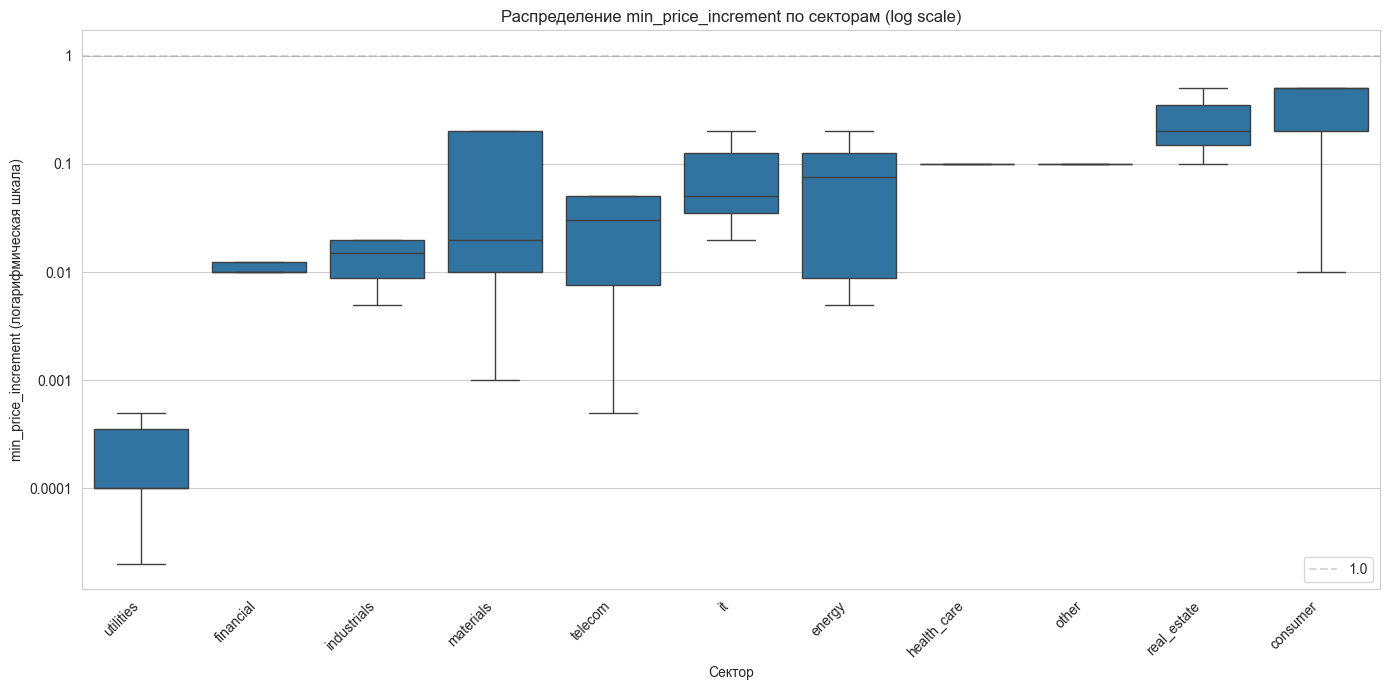

In [ ]:
plt.rcParams["figure.figsize"] = (14, 7)
sns.set_style("whitegrid")

companies = companies[companies['sector'].notna() & (companies['sector'] != '')]

plot_data = companies[companies['min_price_increment'] > 0].copy()

plt.figure(figsize=(14, 7))
ax = sns.boxplot(
    data=plot_data,
    x='sector',
    y='min_price_increment',
    order=plot_data.groupby('sector')['min_price_increment'].median().sort_values().index,
    showfliers=False
)

ax.set_yscale('log')

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda val, pos: f'{val:g}'))

plt.title('Распределение min_price_increment по секторам (log scale)')
plt.xlabel('Сектор')
plt.ylabel('min_price_increment (логарифмическая шкала)')
plt.xticks(rotation=45, ha='right')
plt.axhline(y=1.0, color='gray', linestyle='--', alpha=0.3, label='1.0')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
plot_data['log_increment'] = np.log10(plot_data['min_price_increment'])

stats = plot_data.groupby('sector')['log_increment'].agg([
    ('count', 'count'),
    ('min', 'min'),
    ('median', 'median'),
    ('mean', 'mean'),
    ('max', 'max')
]).round(2)

stats_exp = stats.copy()
for col in ['min', 'median', 'mean', 'max']:
    stats_exp[col] = (10 ** stats_exp[col]).round(6)

print("\nСтатистика min_price_increment по секторам:")
print(stats_exp)


Статистика min_price_increment по секторам:
             count       min    median      mean        max
sector                                                     
consumer         9  0.010000  0.501187  0.223872   0.501187
energy           8  0.005012  0.070795  0.043652   0.501187
financial        8  0.001000  0.010000  0.012023   0.199526
health_care      1  0.100000  0.100000  0.100000   0.100000
industrials      4  0.005012  0.014125  0.012023   0.019953
it               3  0.019953  0.050119  0.058884   0.199526
materials       15  0.001000  0.019953  0.053703  19.952623
other            1  0.100000  0.100000  0.100000   0.100000
real_estate      3  0.100000  0.199526  0.213796   0.501187
telecom          4  0.000501  0.022387  0.010471   0.050119
utilities        7  0.000020  0.000100  0.000155   0.001000


In [ ]:
tickers = companies['ticker']

In [ ]:
tickers

0      SBER
1     SBERP
2      VTBR
4      BSPB
5      SFIN
      ...  
59     SGZH
60     SELG
61     LEAS
62     VSMO
63     IRKT
Name: ticker, Length: 63, dtype: object

In [ ]:
ml_models_data_2025 = pd.read_sql("SELECT * FROM ml_models_data WHERE left_date < '2026-01-01' AND dt < '2026-03-27 20:00:00'", connection())
ml_models_data_2026 = pd.read_sql("SELECT * FROM ml_models_data WHERE left_date > '2026-01-01' AND dt > '2026-03-30 20:00:00' AND dt < '2026-03-31 19:00:00'", connection())

In [ ]:
ml_models_data_2025

,dt,ticker,left_date,right_date,model_name,model_value,train_period,val_period,test_period,step,mape_mean,mae_mean,best_features
0,2026-03-27 17:32:54,SBER,2025-07-01,2025-09-01,DecisionTree,"DecisionTreeRegressor(max_depth=13, min_sample...",21,14,7,7,0.008,2.629,"[""RTSTN_open_rm_20"", ""RUABITR_open_lag_12"", ""R..."
1,2026-03-27 17:32:57,SBER,2025-07-01,2025-09-01,RandomForest,"RandomForestRegressor(max_depth=8, max_feature...",21,14,7,7,0.007,2.329,"[""RUCBTRNS_open_rm_4"", ""RUCBTRNS_open_lag_15"",..."
2,2026-03-27 17:33:35,SBER,2025-07-01,2025-09-01,XGBoost,"XGBRegressor(base_score=None, booster=None, ca...",21,14,7,7,0.013,4.153,"[""RUABITR_open_lag_12"", ""RUBMI_open_rm_5"", ""RU..."
3,2026-03-27 17:33:36,SBER,2025-07-01,2025-09-01,LightGBM,LGBMRegressor(colsample_bytree=0.9627992777258...,21,14,7,7,0.006,2.012,"[""RTSTN_open_rm_20"", ""RUABITR_open_lag_12"", ""R..."
4,2026-03-27 17:35:07,SBER,2025-07-01,2025-09-01,CatBoost,<catboost.core.CatBoostRegressor object at 0x3...,21,14,7,7,0.007,2.297,"[""RUBMI_open_rm_11"", ""RUGOLD_open_lag_3"", ""RUC..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
240,2026-03-27 19:44:09,IRKT,2025-07-01,2025-09-01,DecisionTree,"DecisionTreeRegressor(max_depth=6, max_feature...",21,14,7,7,0.038,1.108,"[""RTSTN_open_rm_20"", ""RUABITR_open_lag_12"", ""R..."
241,2026-03-27 19:44:12,IRKT,2025-07-01,2025-09-01,RandomForest,"RandomForestRegressor(bootstrap=False, max_dep...",21,14,7,7,0.036,1.054,"[""RUMBTRNS_open_lag_11"", ""RUGOLD_open_rm_11"", ..."
242,2026-03-27 19:44:48,IRKT,2025-07-01,2025-09-01,XGBoost,"XGBRegressor(base_score=None, booster=None, ca...",21,14,7,7,0.025,0.734,"[""RUBMI_open_rm_11"", ""RUGOLD_open_lag_3"", ""RUC..."
243,2026-03-27 19:44:49,IRKT,2025-07-01,2025-09-01,LightGBM,LGBMRegressor(colsample_bytree=0.9544076167691...,21,14,7,7,0.038,1.108,"[""RTSTN_open_rm_20"", ""RUABITR_open_lag_12"", ""R..."


In [ ]:
ml_models_data_2026

,dt,ticker,left_date,right_date,model_name,model_value,train_period,val_period,test_period,step,mape_mean,mae_mean,best_features
0,2026-03-30 21:11:18,CBOM,2026-01-12,2026-03-12,CatBoost,<catboost.core.CatBoostRegressor object at 0x1...,21,14,7,7,0.084,0.477,"[""RUGOLD_open_rm_6"", ""low_lag_10"", ""tfidf_\u04..."
1,2026-03-30 21:06:06,SBER,2026-01-12,2026-03-12,DecisionTree,"DecisionTreeRegressor(max_depth=13, min_sample...",21,14,7,7,0.033,10.435,"[""RUGOLD_open_rm_6"", ""RUABITR_open_rm_3"", ""RUP..."
2,2026-03-30 21:06:07,SBER,2026-01-12,2026-03-12,RandomForest,"RandomForestRegressor(bootstrap=False, max_dep...",21,14,7,7,0.029,9.013,"[""RUGOLD_open_rm_6"", ""RUABITR_open_rm_3"", ""RUP..."
3,2026-03-30 21:06:29,SBER,2026-01-12,2026-03-12,XGBoost,"XGBRegressor(base_score=None, booster=None, ca...",21,14,7,7,0.027,8.546,"[""RUGOLD_open_rm_6"", ""tfidf_\u043f\u043e\u0434..."
4,2026-03-30 21:11:45,BSPB,2026-01-12,2026-03-12,DecisionTree,"DecisionTreeRegressor(max_depth=2, max_feature...",21,14,7,7,0.040,13.458,"[""RUGOLD_open_rm_6"", ""RUABITR_open_rm_3"", ""RUP..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
220,2026-03-30 22:22:52,SELG,2026-01-12,2026-03-12,CatBoost,<catboost.core.CatBoostRegressor object at 0x3...,21,14,7,7,0.043,2.499,"[""low_rm_21"", ""RUGOLD_open_rm_9"", ""macd_lag_22..."
221,2026-03-30 22:23:30,IRKT,2026-01-12,2026-03-12,DecisionTree,"DecisionTreeRegressor(max_depth=3, max_feature...",21,14,7,7,0.079,1.997,"[""RUGOLD_open_rm_6"", ""RUABITR_open_rm_3"", ""RUP..."
222,2026-03-30 22:23:31,IRKT,2026-01-12,2026-03-12,RandomForest,"RandomForestRegressor(bootstrap=False, max_dep...",21,14,7,7,0.052,1.308,"[""RUGOLD_open_rm_6"", ""RUABITR_open_rm_3"", ""RUP..."
223,2026-03-30 22:23:41,IRKT,2026-01-12,2026-03-12,XGBoost,"XGBRegressor(base_score=None, booster=None, ca...",21,14,7,7,0.062,1.554,"[""RUGOLD_open_rm_6"", ""high_lag_21_low_lag_21_d..."


In [ ]:
ml_models_data_2025[['mape_mean', 'mae_mean']].describe()

,mape_mean,mae_mean
count,245.000000,245.000000
mean,0.058212,166.083388
std,0.037502,890.339028
min,0.006000,0.006000
25%,0.029000,1.108000
50%,0.046000,6.219000
75%,0.084000,23.292000
max,0.198000,6835.714000


In [ ]:
ml_models_data_2026[['mape_mean', 'mae_mean']].describe()

,mape_mean,mae_mean
count,225.000000,225.000000
mean,0.044316,40.091969
std,0.032655,107.247081
min,0.003000,0.008000
25%,0.019000,1.063000
50%,0.035000,3.429000
75%,0.065000,38.424000
max,0.160000,698.345000


In [ ]:
for ticker in tickers:
    ticker_data = ml_models_data_2025[ml_models_data_2025["ticker"] == ticker].copy()

    if ticker_data.empty:
        continue

    print(f"\n{'=' * 60}")
    print(f"Ticker: {ticker}")
    print(f"{'=' * 60}")

    for idx, row in ticker_data.iterrows():
        print(f"\nМодель: {row['model_name']}")
        print(f"Лучшие признаки: {row['best_features']}")

    print(f"\n{'=' * 60}")


Ticker: SBER

Модель: DecisionTree
Лучшие признаки: ["RTSTN_open_rm_20", "RUABITR_open_lag_12", "RUBMI_open_rm_5", "RUCBTRNS_open_lag_13", "RUPMI_open_lag_19", "RUPCI_open_lag_15", "RUSFAR1M_open_rm_7", "RUSFAR_open_lag_21", "RUPMI_open_lag_5", "RUGOLD_open_rm_12", "RUBMI_open_lag_21", "RTSI_open_rm_9", "RUGOLD_open_rm_4", "RUABITR_open_rm_15", "RUGOLD_open_rm_8", "RUSFAR_open_lag_13", "RUPAI_open_lag_5", "RUSFAR1M_open_lag_10", "RUABITR_open_lag_14", "RTSI_open_rm_6", "RTSTN_open_lag_19", "RUSFAR1MRT_open_lag_1", "RUPAI_open_rm_11", "RUABITR_open_rm_22", "RUGOLD_open_lag_5", "RUPAI_open_lag_9", "RUCBTRNS_open_rm_19", "boll_lb_lag_22", "RUPCI_open_lag_17", "RUPAI_open_rm_7", "RUCBTRNS_open_rm_12", "RUGOLD_open_rm_3", "RUCBTRNS_open_lag_8", "RUPCI_open_lag_18", "RUSFAR1M_open_rm_17", "RUSFAR1MRT_open_rm_12", "RUMBTRNS_open_rm_6", "RUBMI_open_lag_8", "RUPAI_open_rm_9", "RUSFAR1M_open_rm_15", "RTSTN_open_lag_17", "RUPMI_open_rm_16", "RUBMI_open_lag_20", "RUBMI_open_rm_22", "RUPMI_open_rm

In [ ]:
for ticker in tickers:
    ticker_data = ml_models_data_2026[ml_models_data_2026["ticker"] == ticker].copy()

    if ticker_data.empty:
        continue

    print(f"\n{'=' * 60}")
    print(f"Ticker: {ticker}")
    print(f"{'=' * 60}")

    for idx, row in ticker_data.iterrows():
        print(f"\nМодель: {row['model_name']}")
        print(f"Лучшие признаки: {row['best_features']}")

    print(f"\n{'=' * 60}")


Ticker: SBER

Модель: DecisionTree
Лучшие признаки: ["RUGOLD_open_rm_6", "RUABITR_open_rm_3", "RUPAI_open_lag_21", "RUABITR_open_rm_17", "RUSFAR_open_rm_16", "RUCBTRNS_open_rm_6", "RUGOLD_open_lag_15", "RUPCI_open_rm_17", "RTSTN_open_rm_20", "RUGOLD_open_rm_22", "RTSTN_open_lag_18", "RUSFAR1M_open_rm_22", "RUBMI_open_rm_21", "RUPMI_open_lag_20", "RUBMI_open_lag_18", "RUMBTRNS_open_lag_21", "RUSFAR1M_open_lag_22", "RUPMI_open_rm_14", "RUSFAR_open_rm_6", "RUSFAR_open_rm_20", "RTSI_open_lag_5", "RTSTN_open_lag_15", "RUMBTRNS_open_rm_6", "RUPCI_open_lag_12", "RUSFAR1MRT_open_lag_3", "RUBMI_open_rm_10", "RUCBTRNS_open_lag_8", "RUGOLD_open_lag_12", "RUGOLD_open_lag_14", "RUCBTRNS_open_lag_20", "RUPAI_open_rm_17", "RTSTN_open_rm_17", "RUCBTRNS_open_rm_2", "RUSFAR1MRT_open_lag_9", "RUPMI_open_lag_8", "RUMBTRNS_open_lag_5", "RUMBTRNS_open_rm_12", "RUABITR_open_rm_13", "RUPCI_open_lag_19", "RUPAI_open_rm_13", "RUCBTRNS_open_rm_3", "RUSFAR1M_open_rm_13", "RUSFAR_open_rm_5", "RUMBTRNS_open_lag_2"

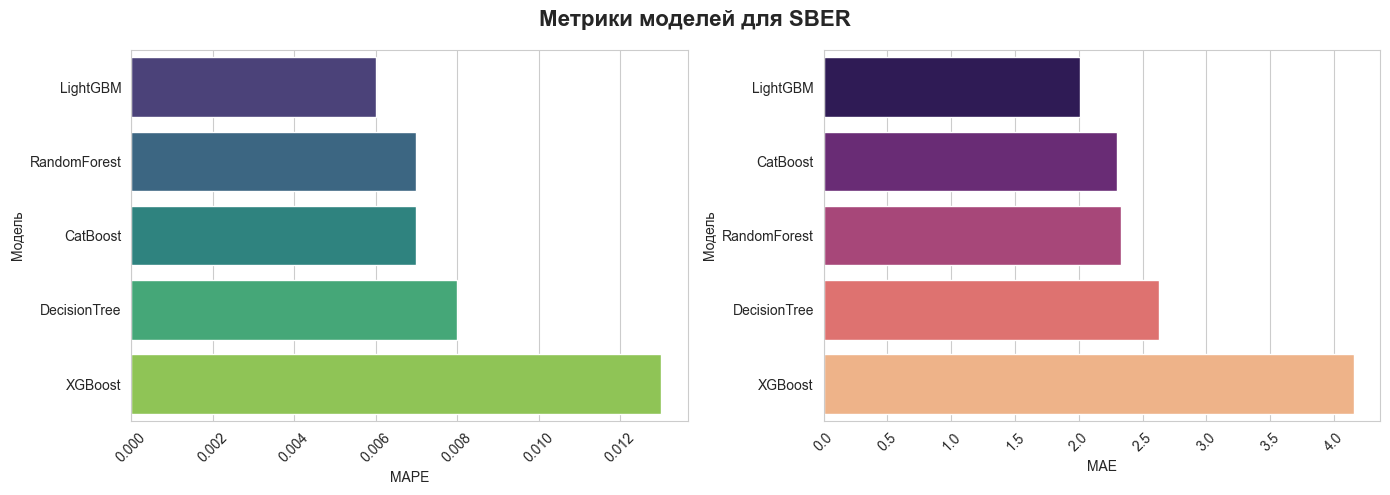

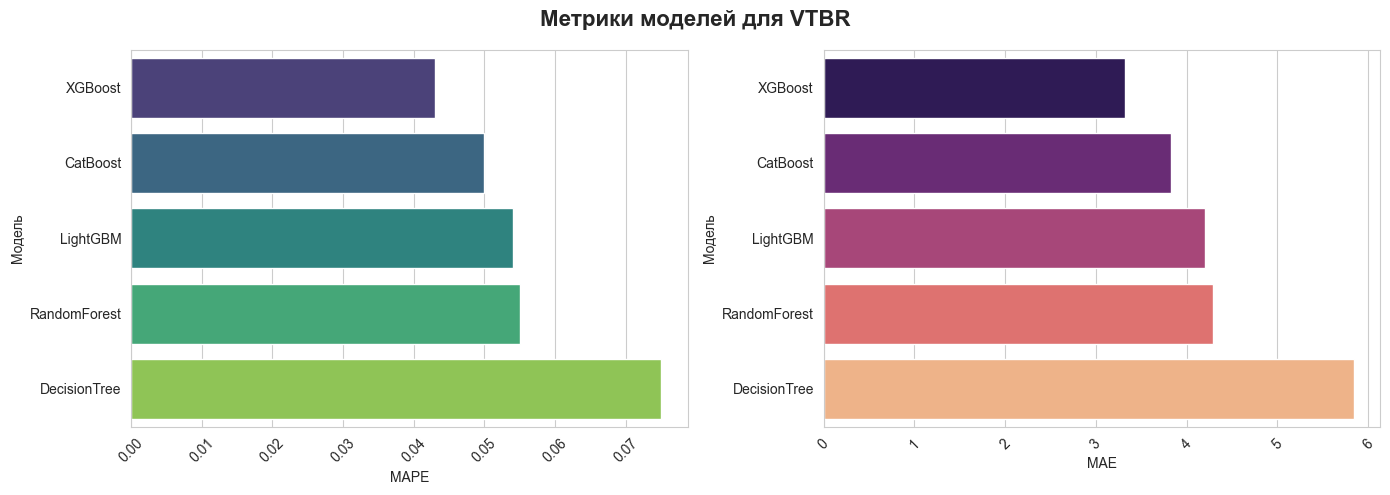

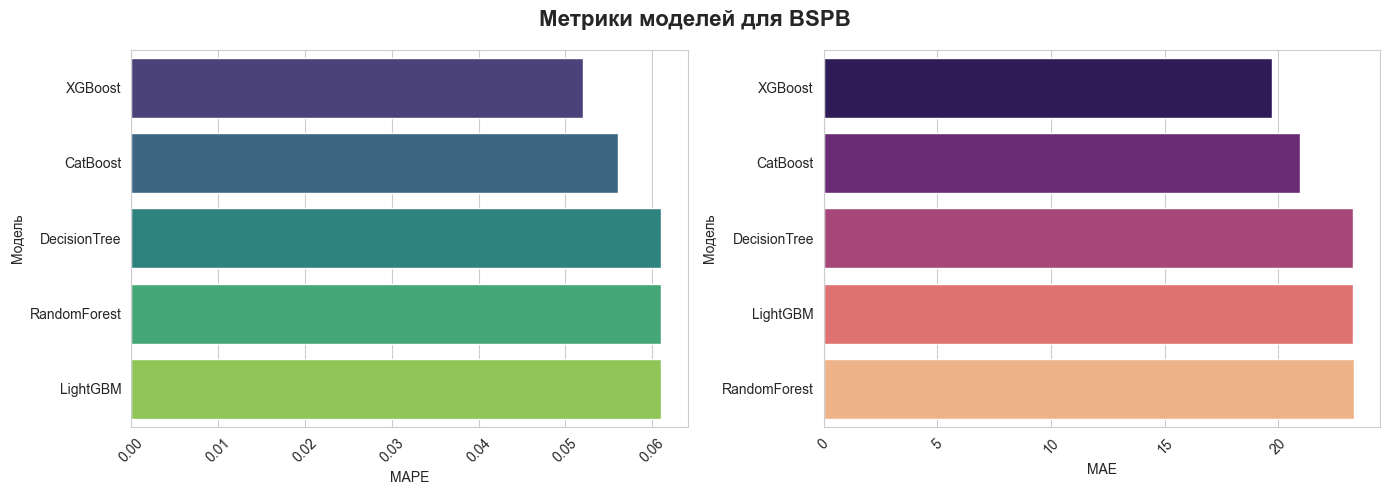

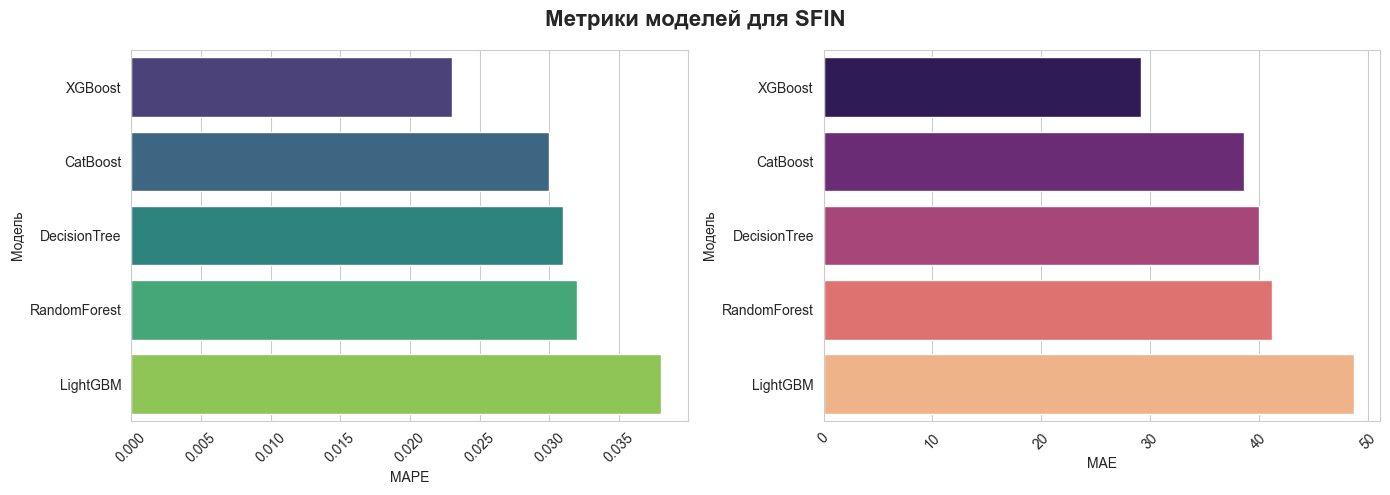

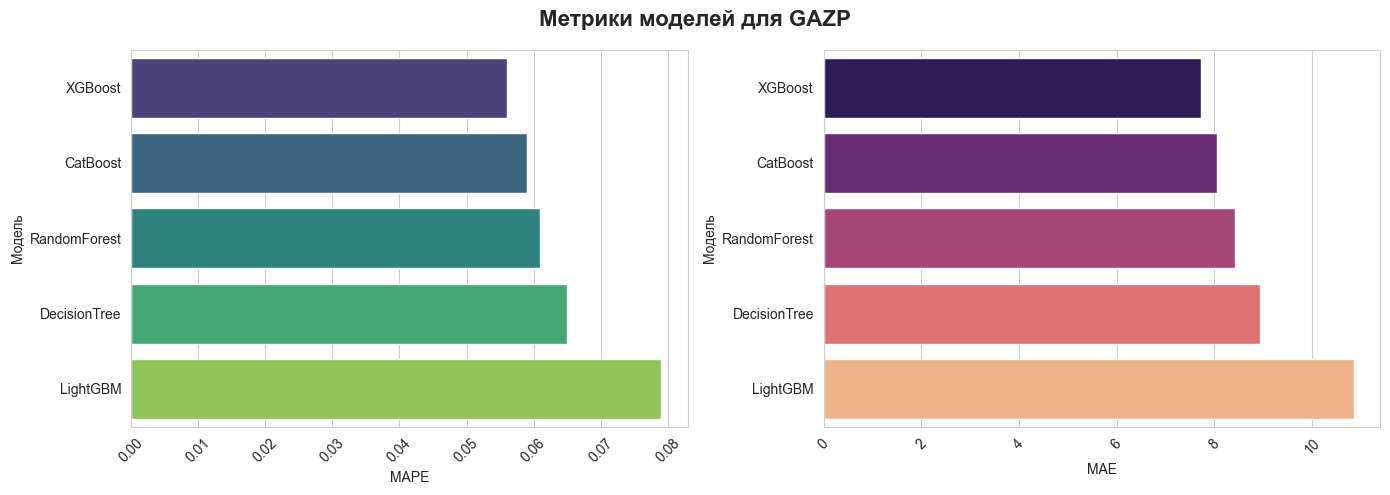

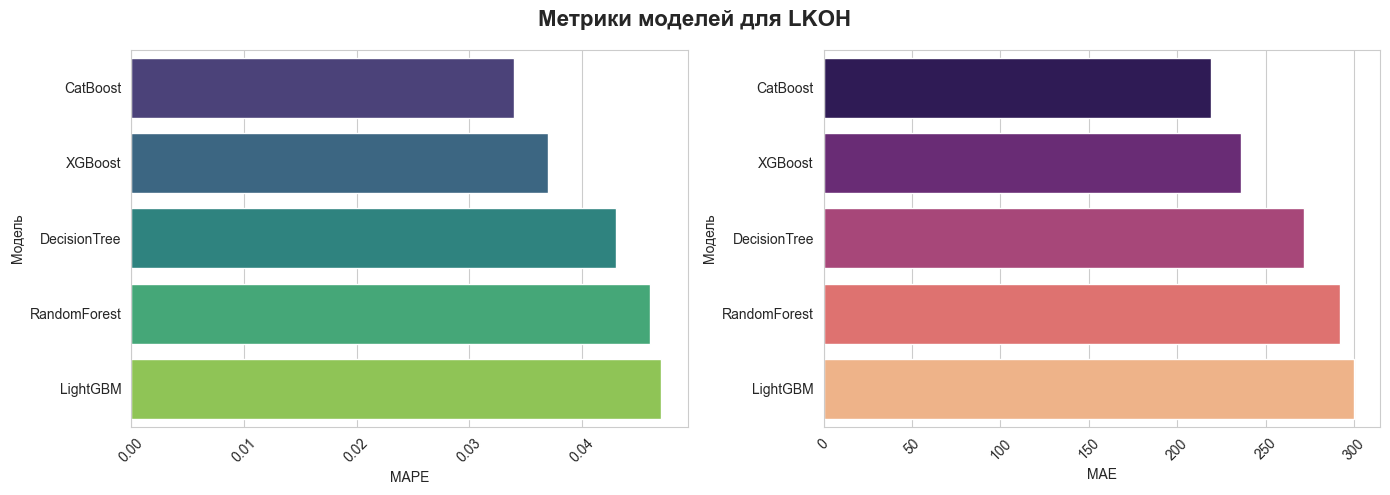

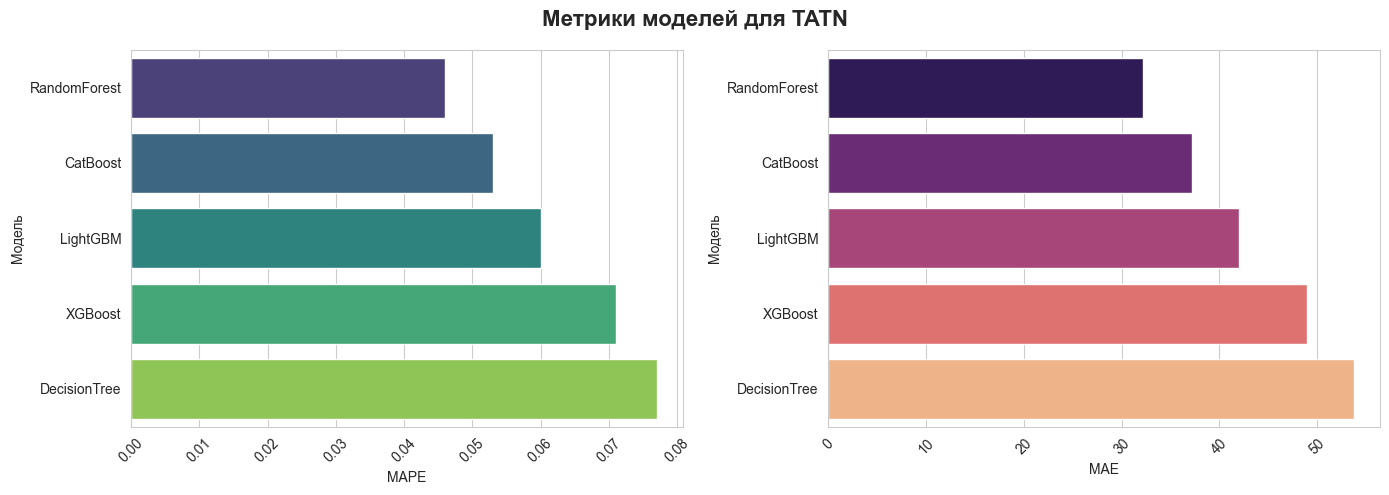

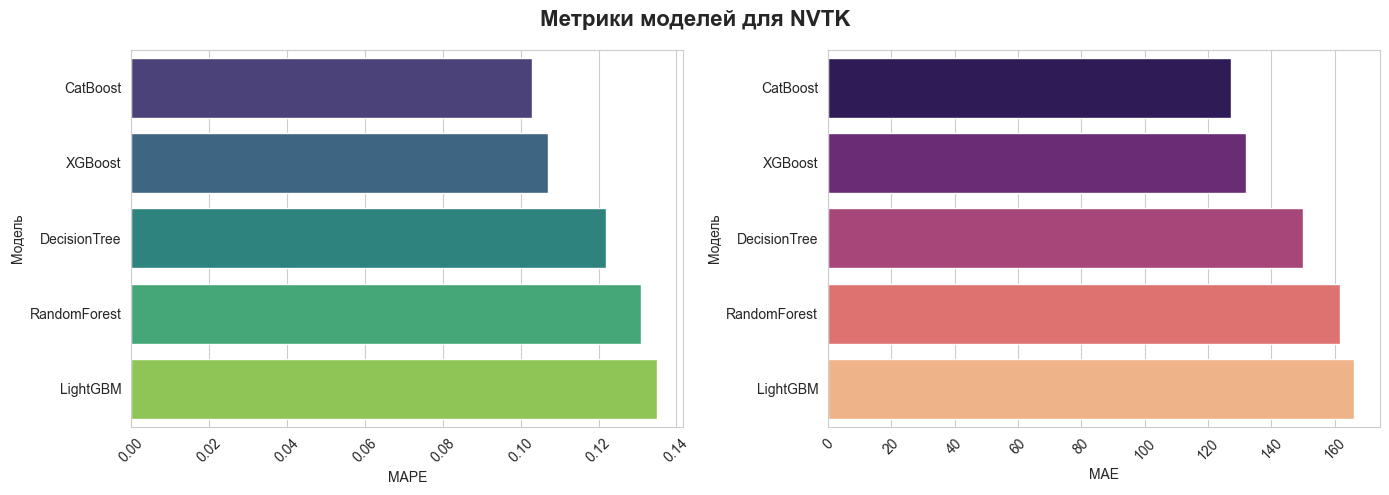

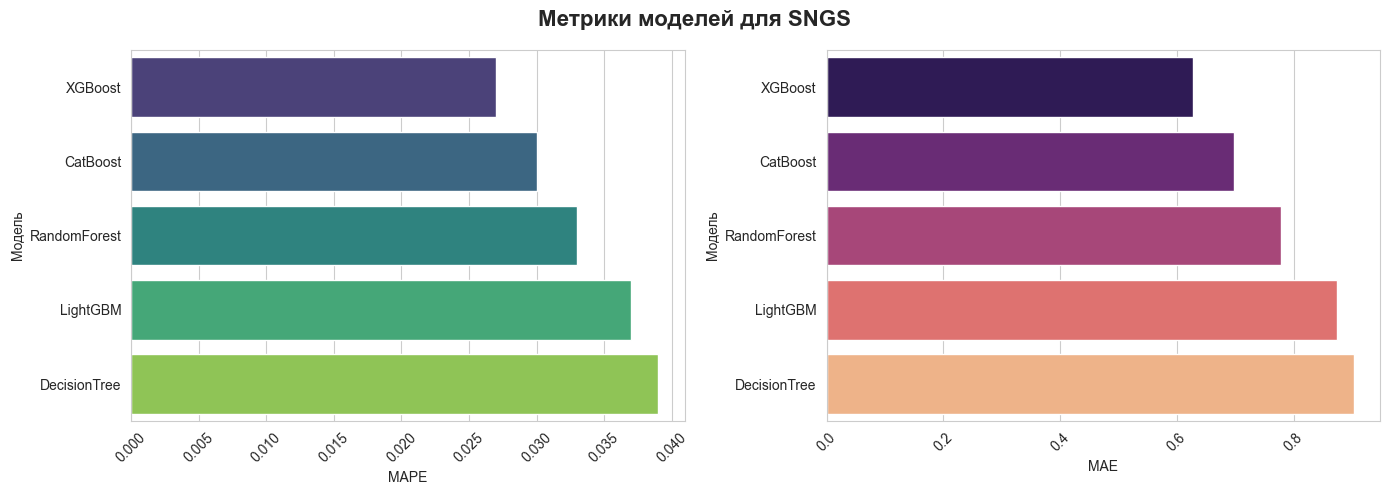

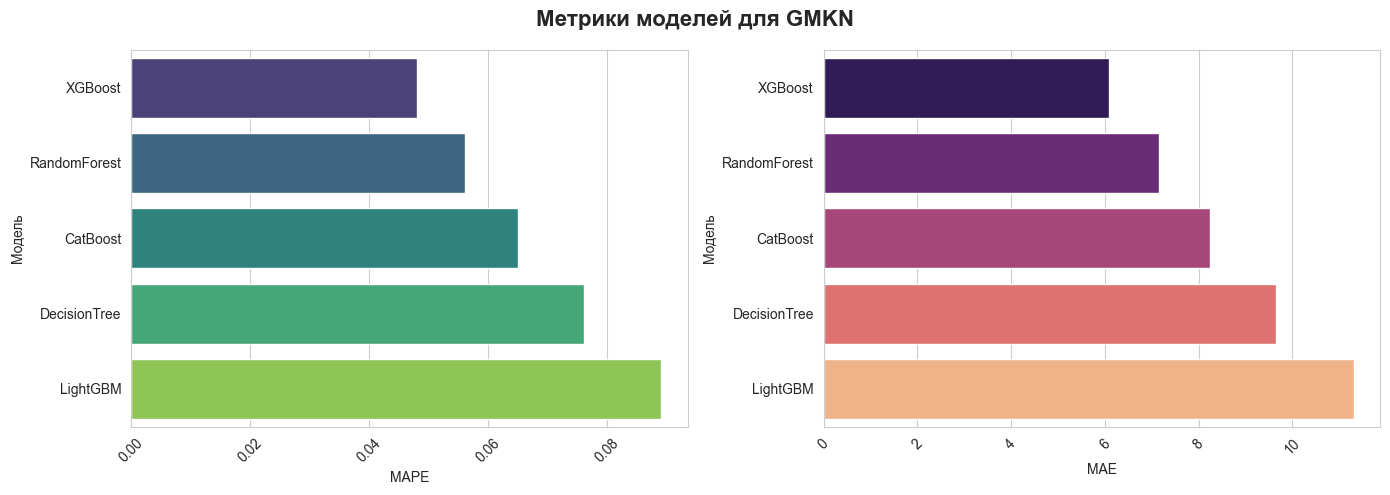

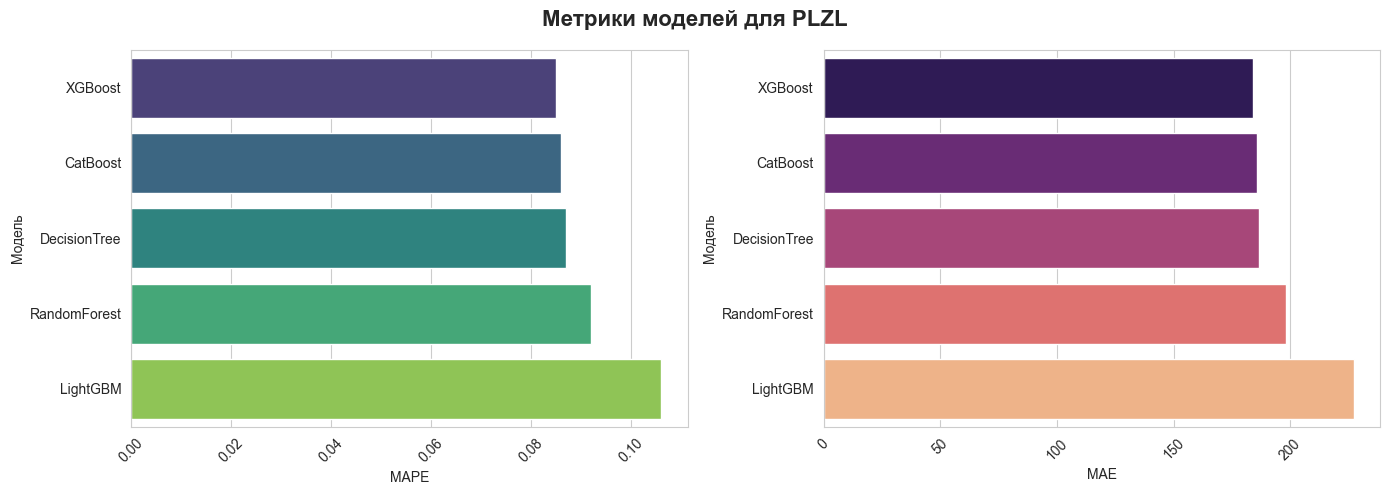

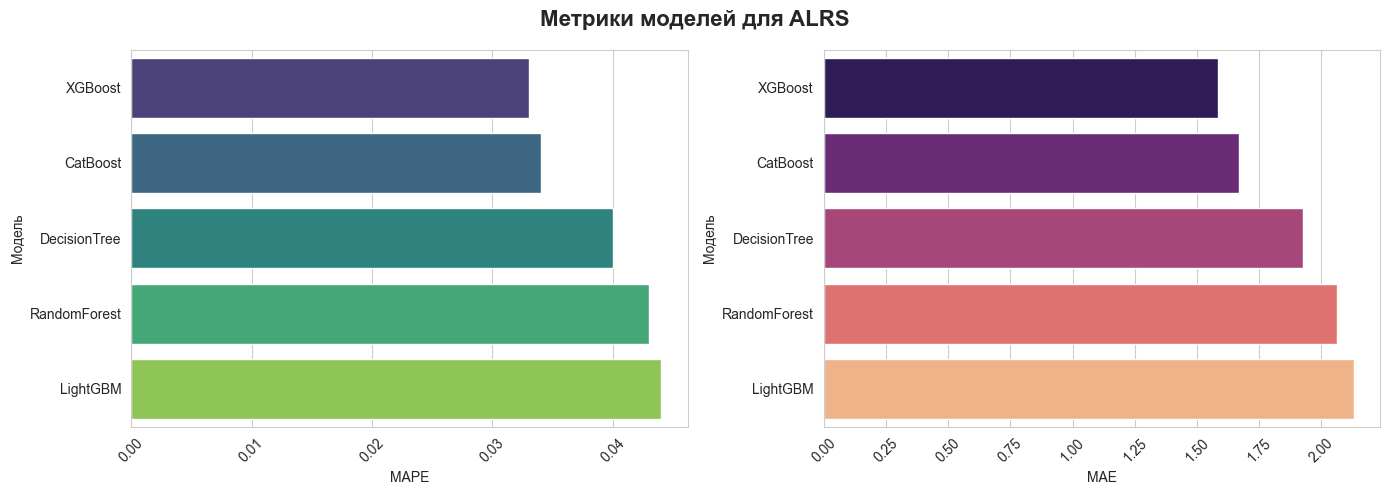

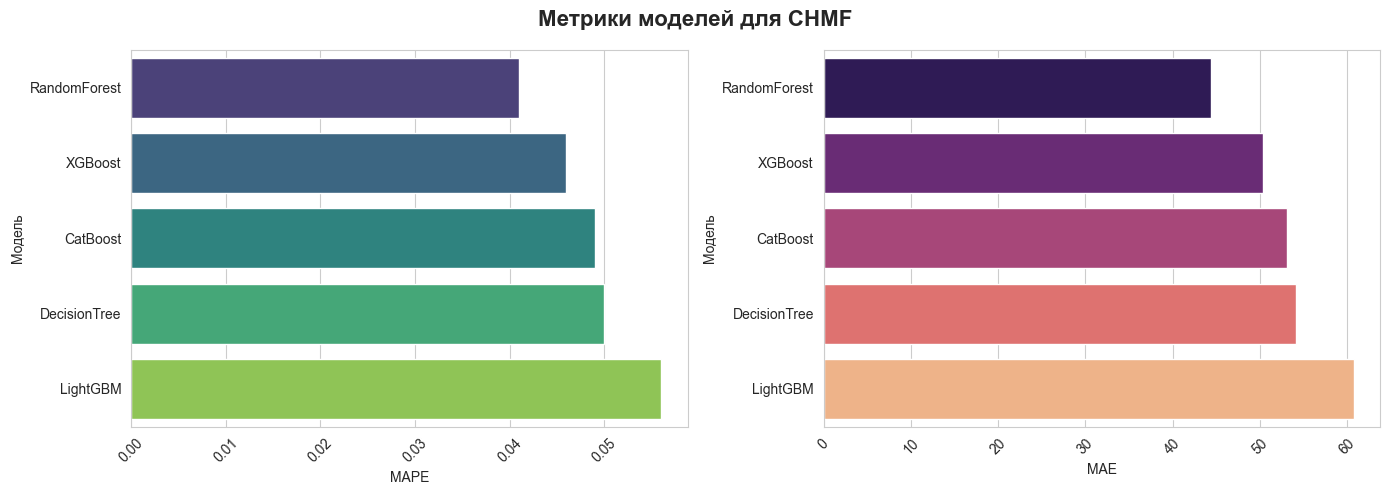

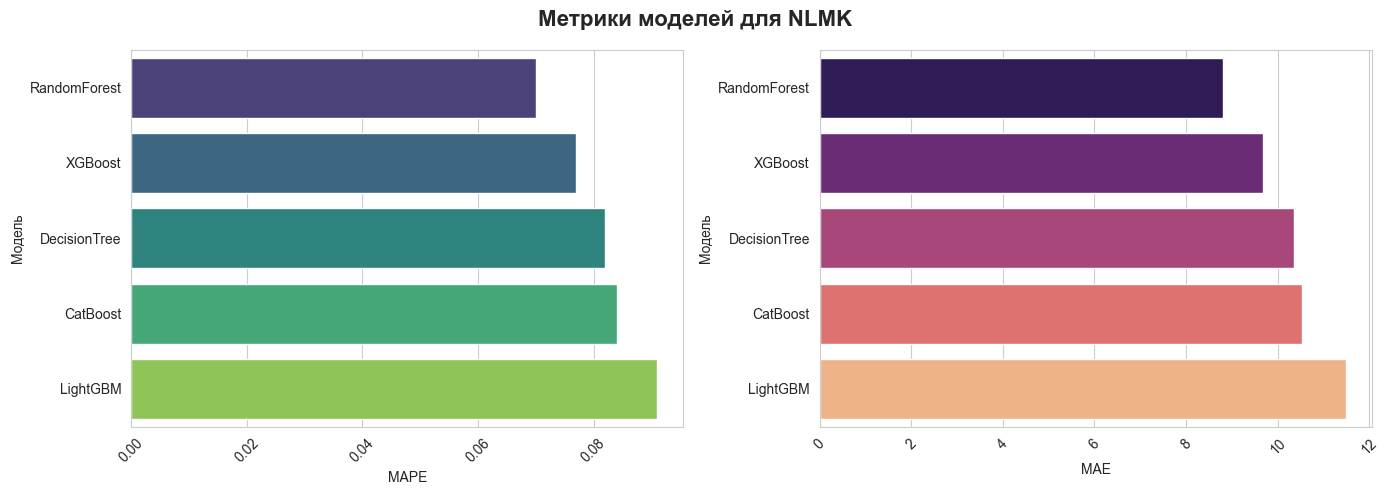

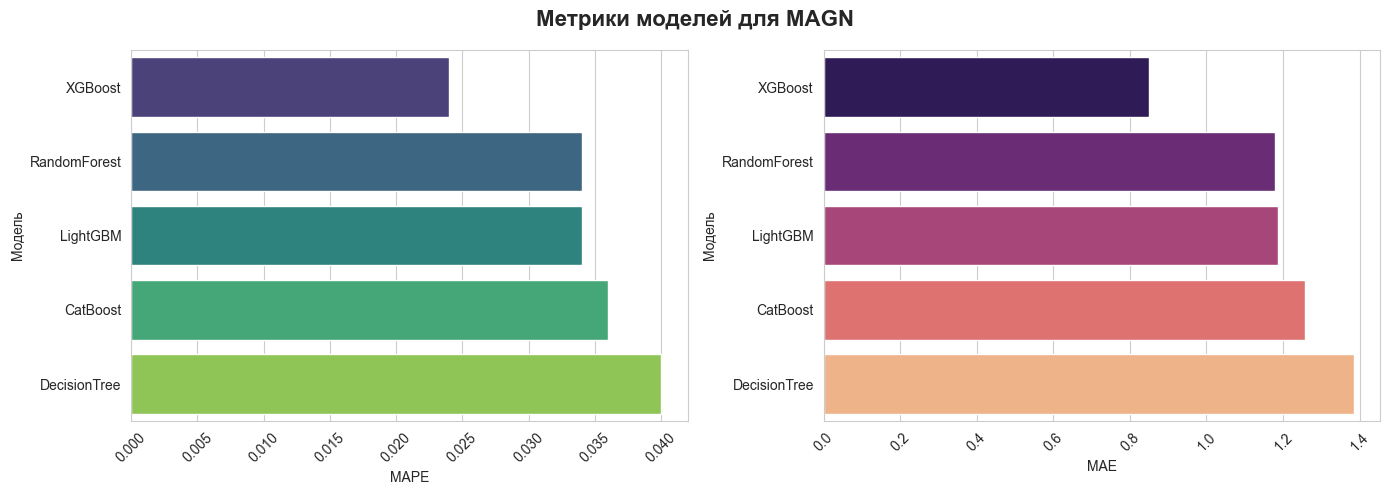

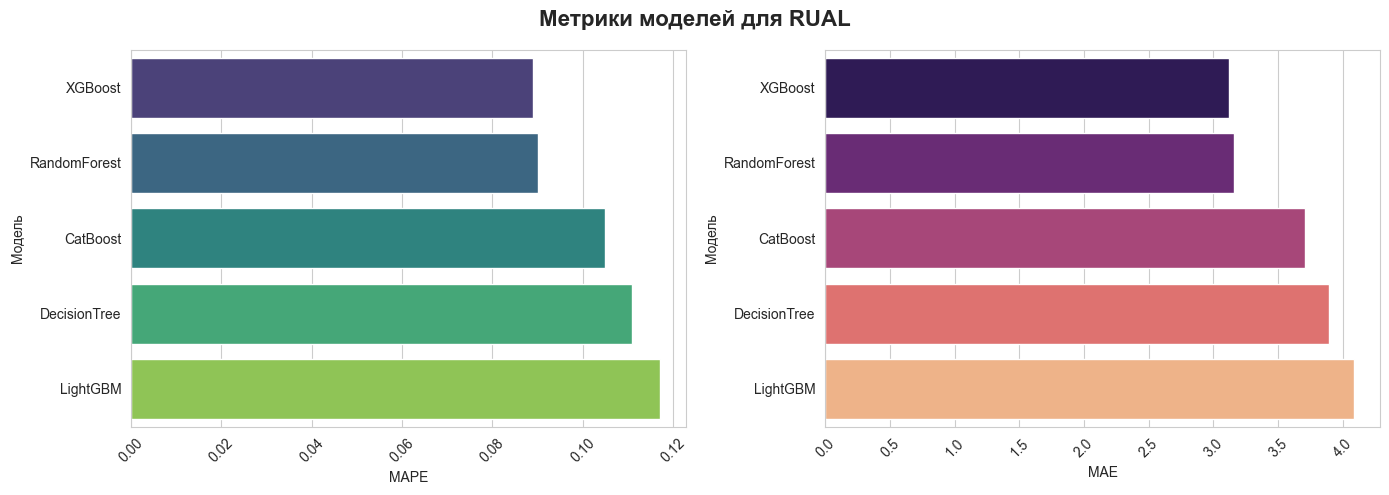

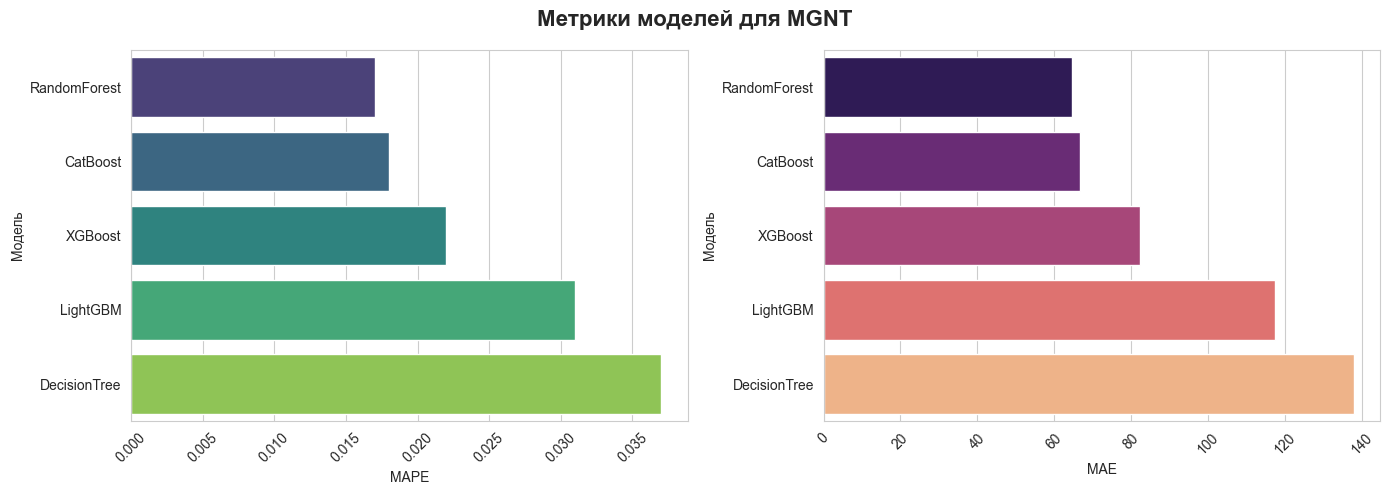

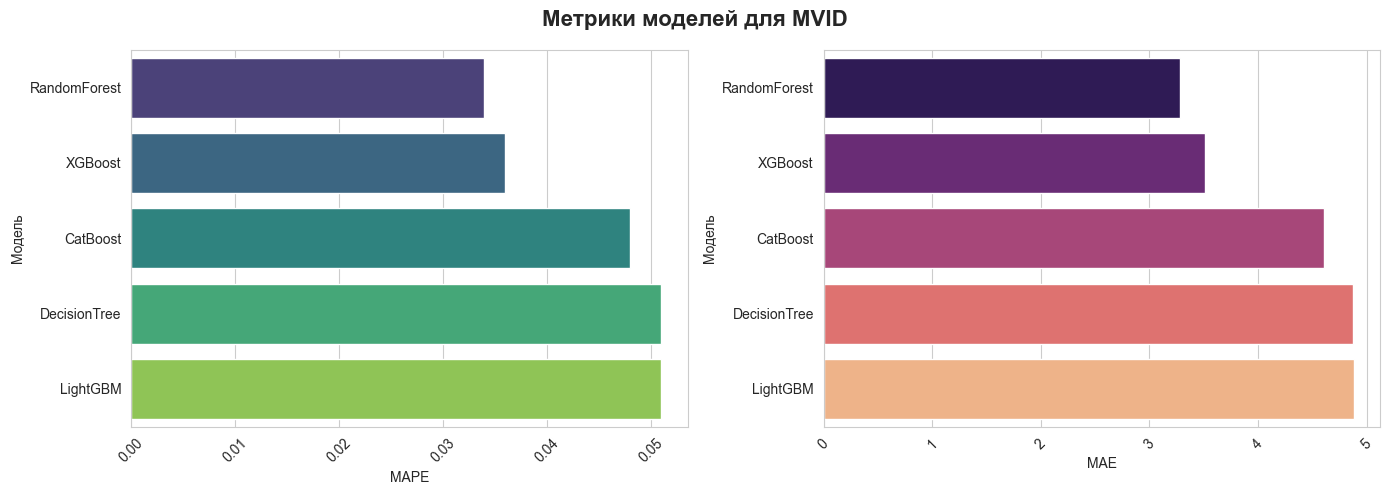

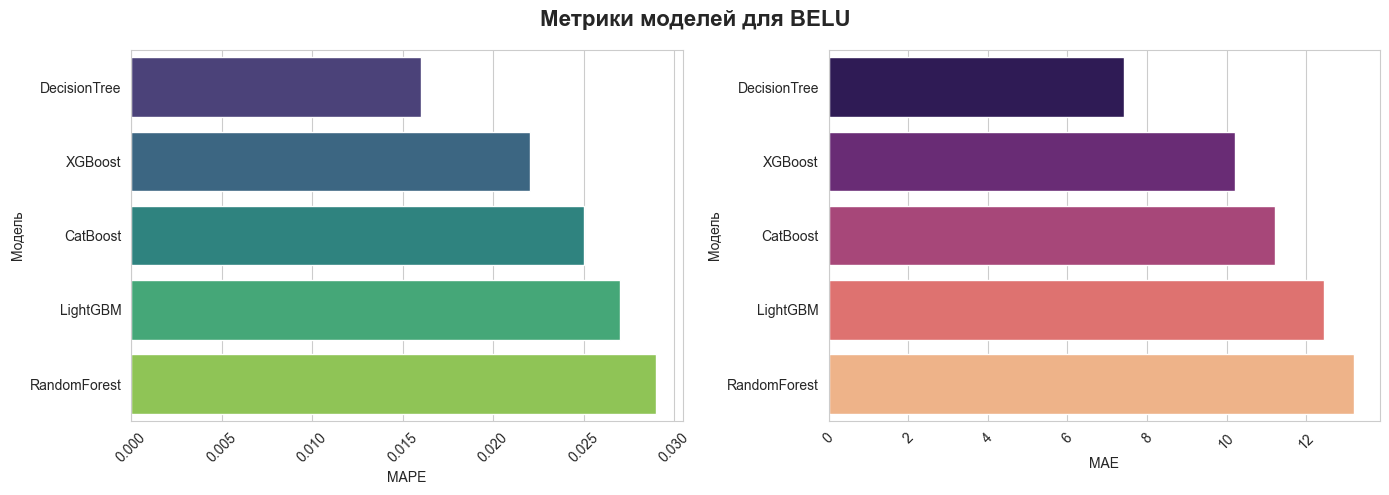

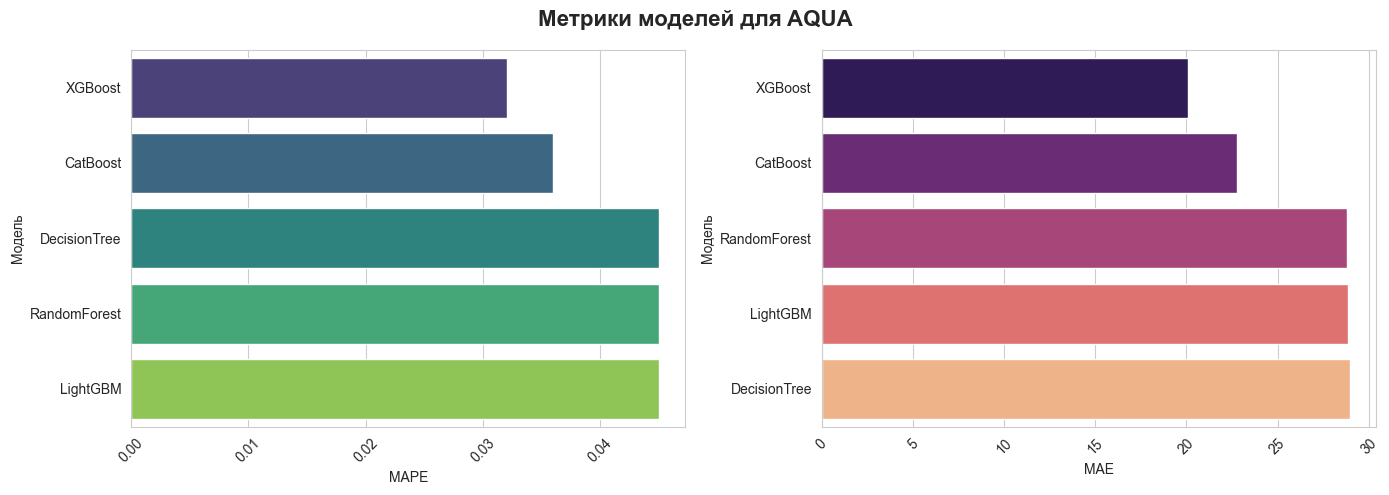

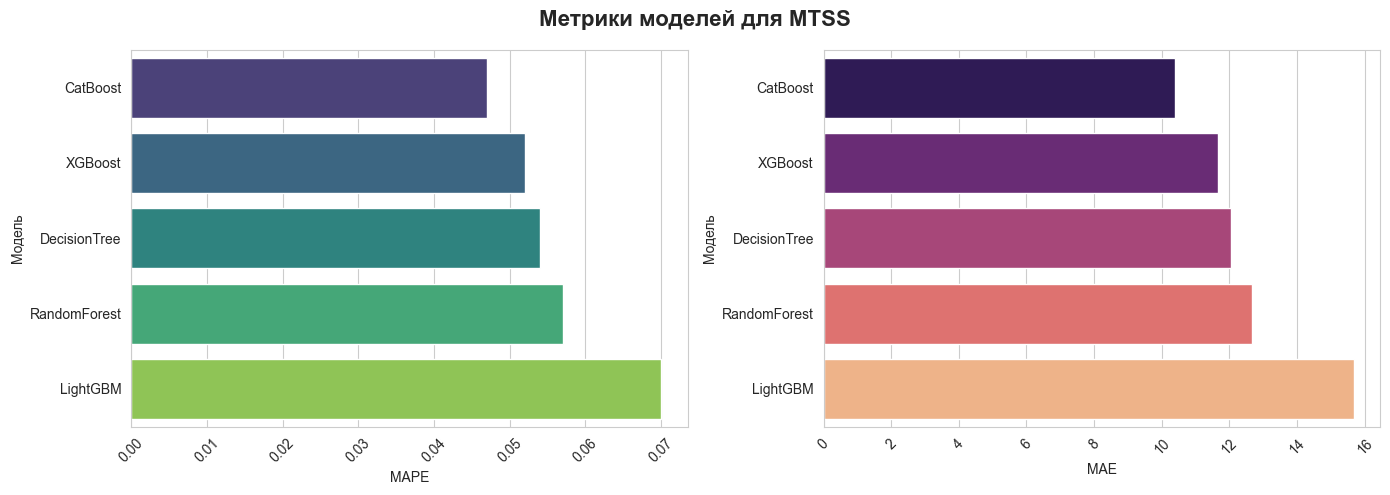

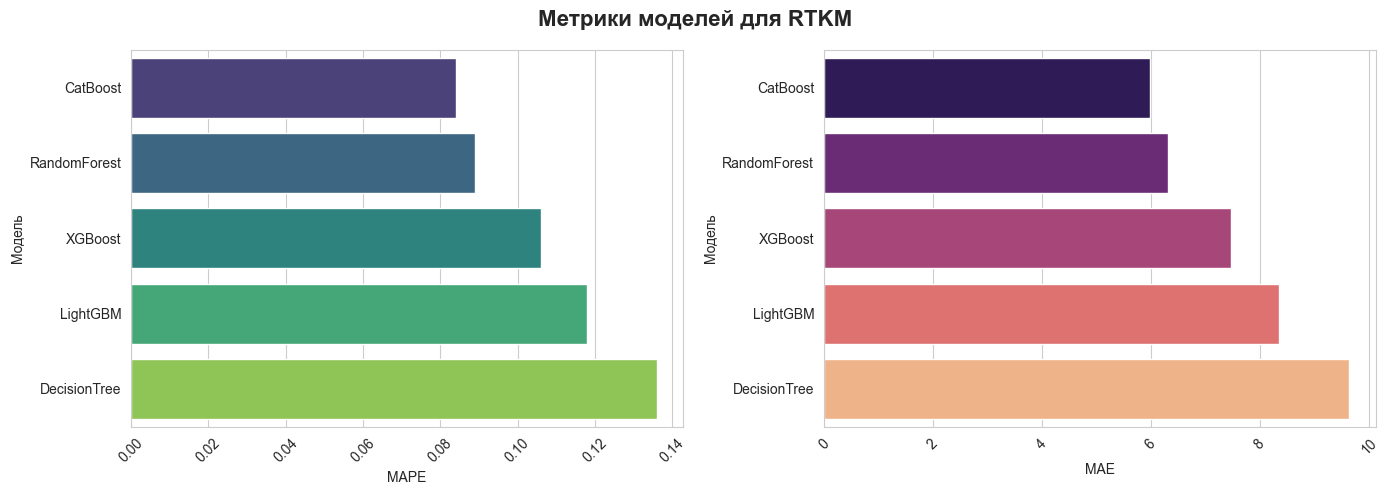

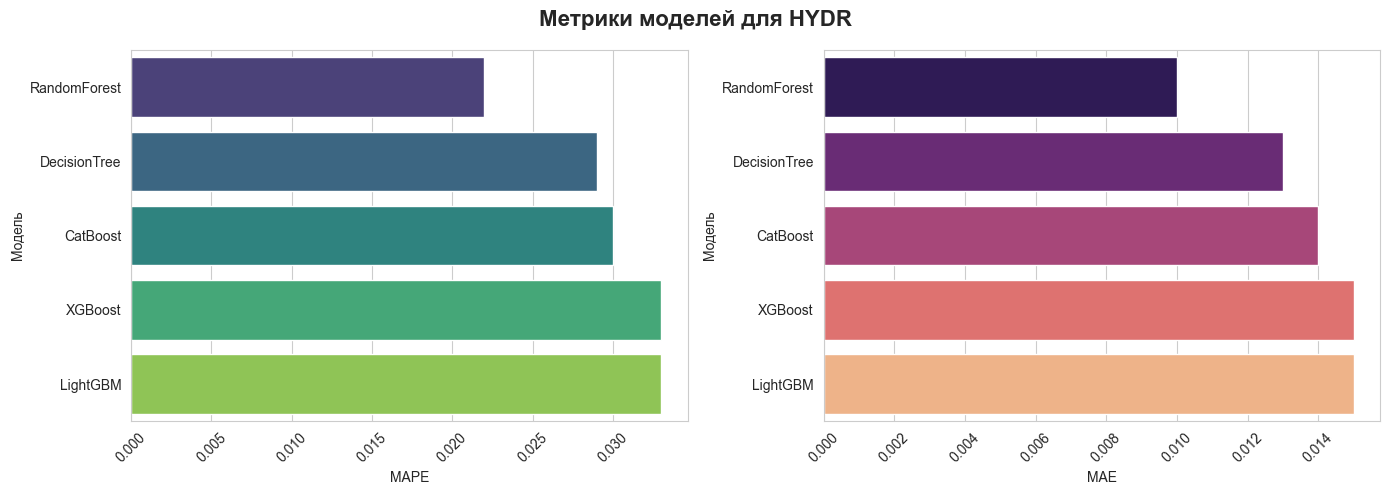

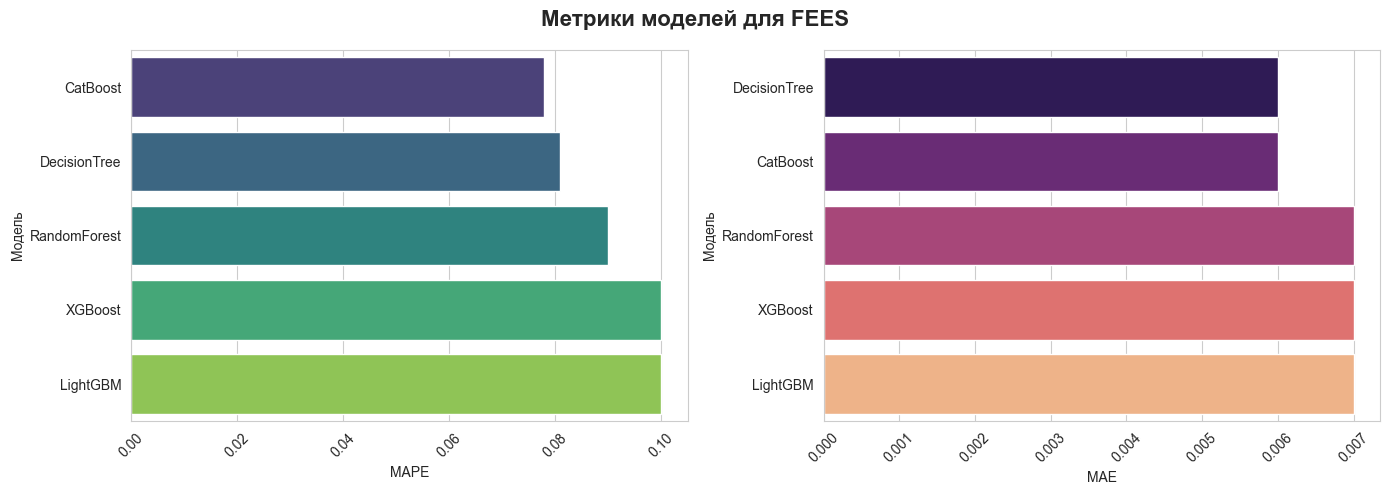

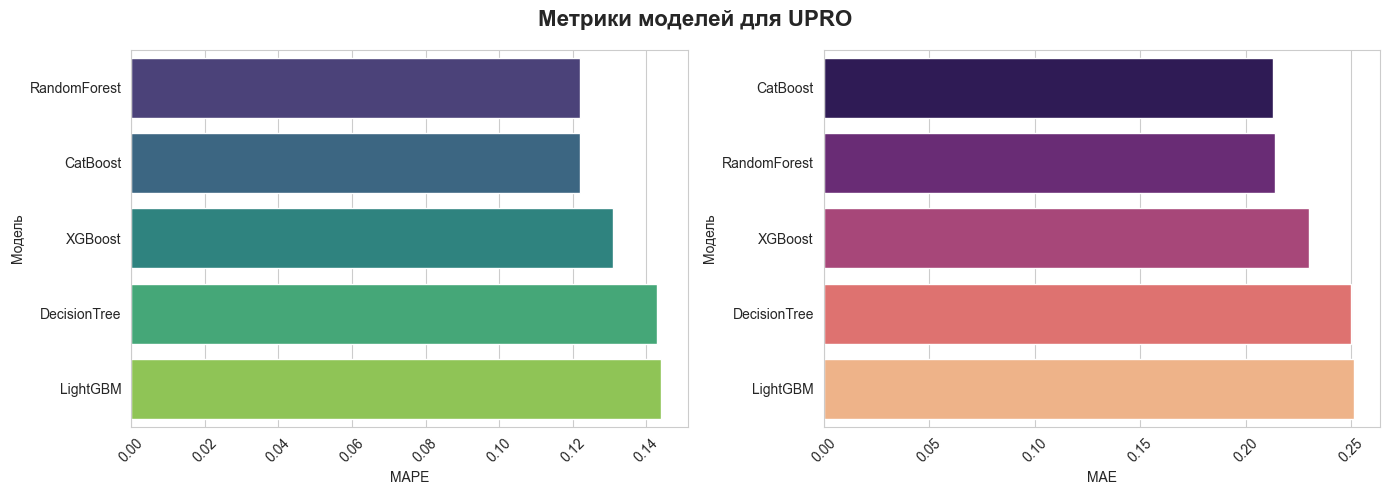

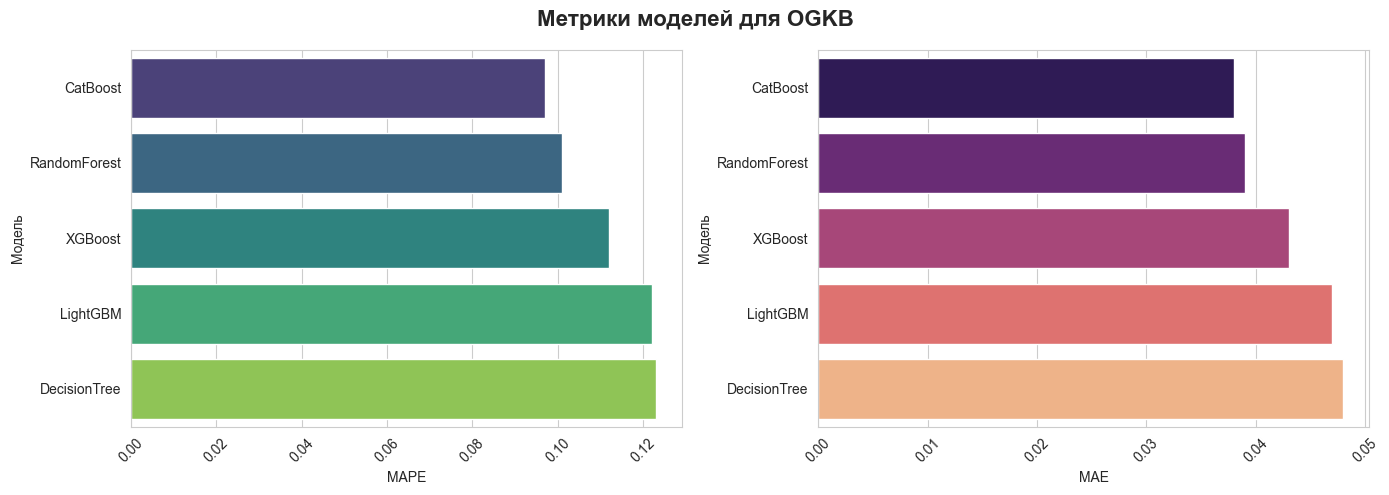

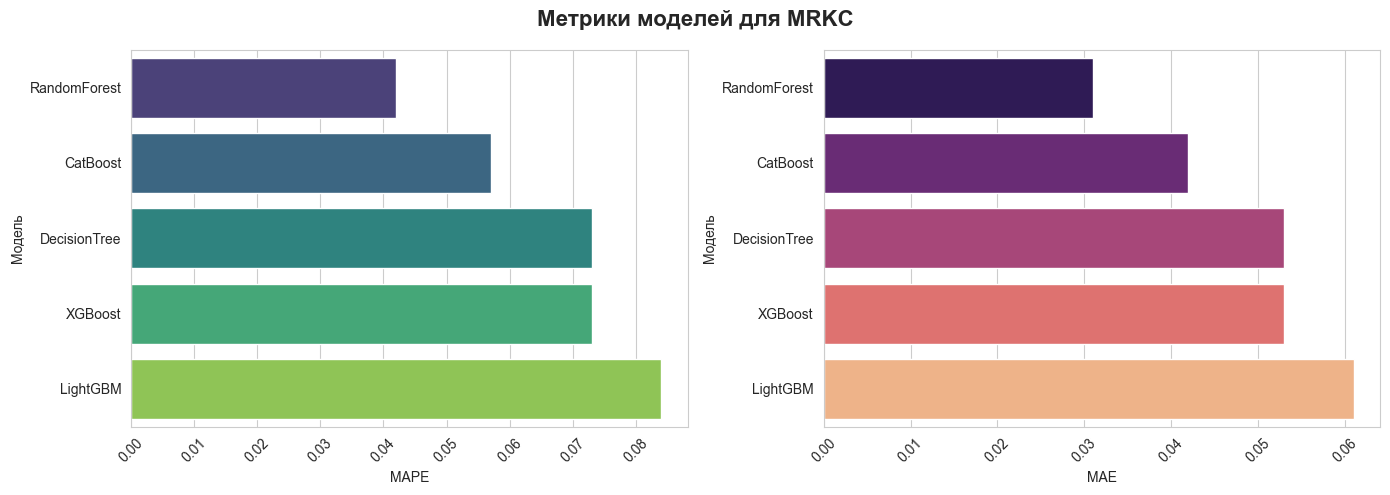

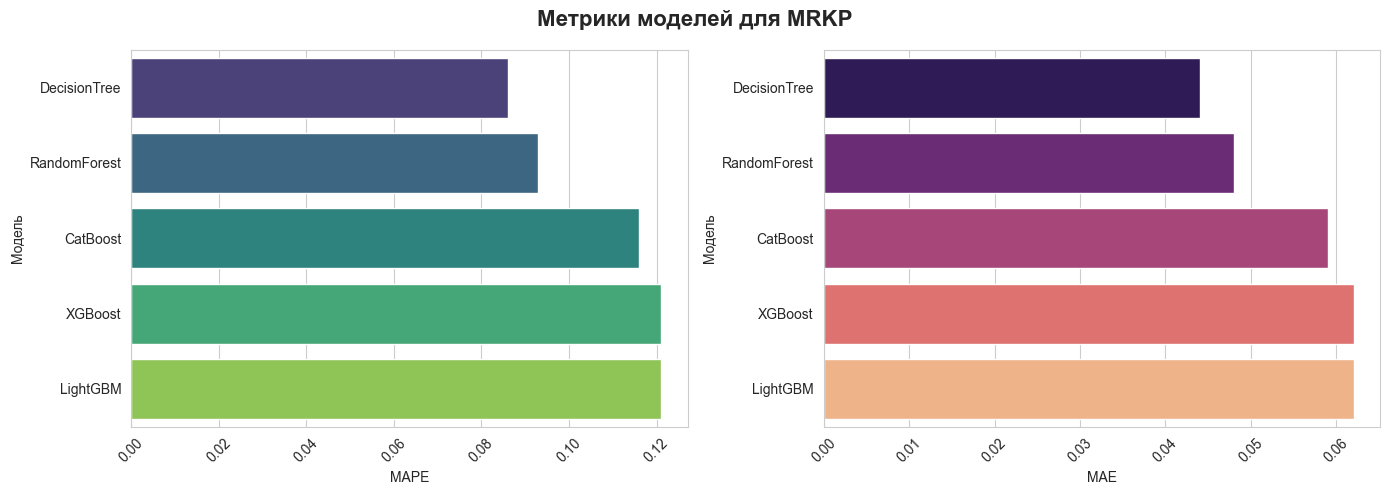

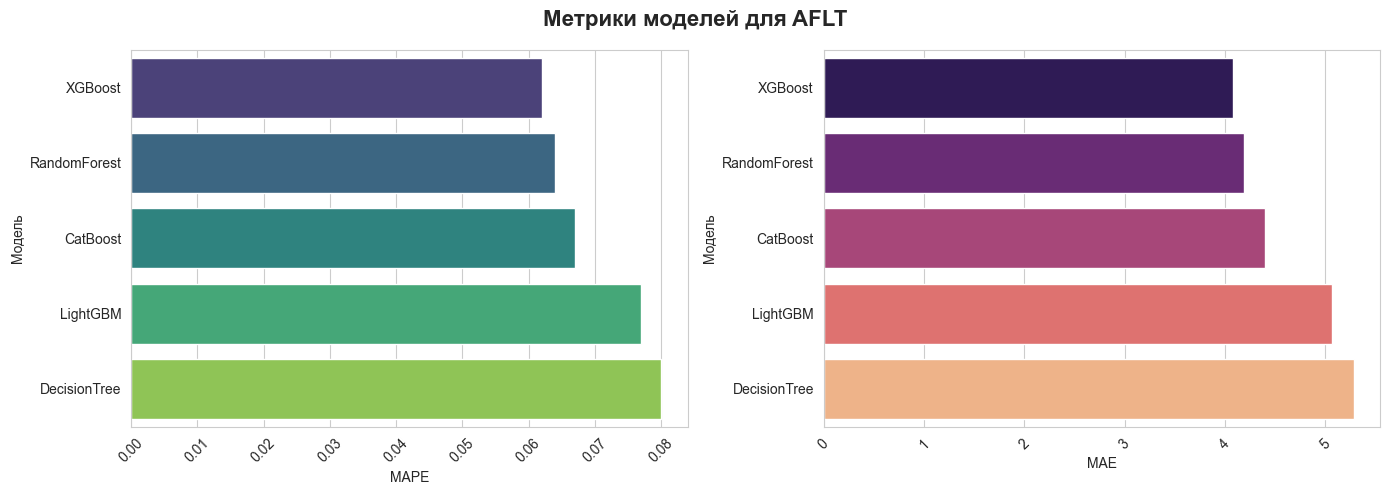

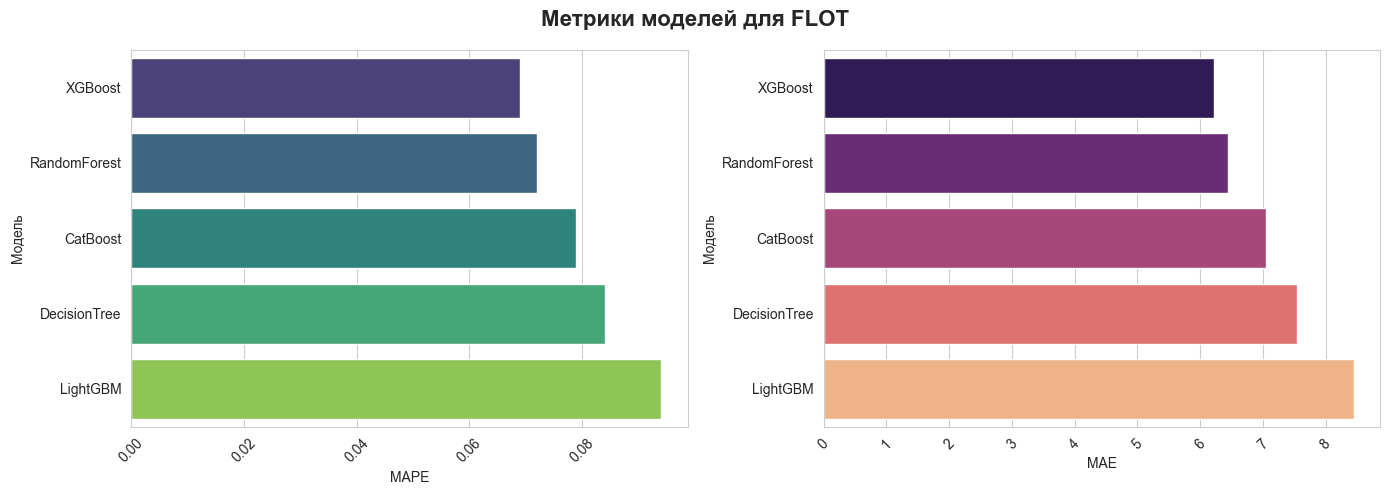

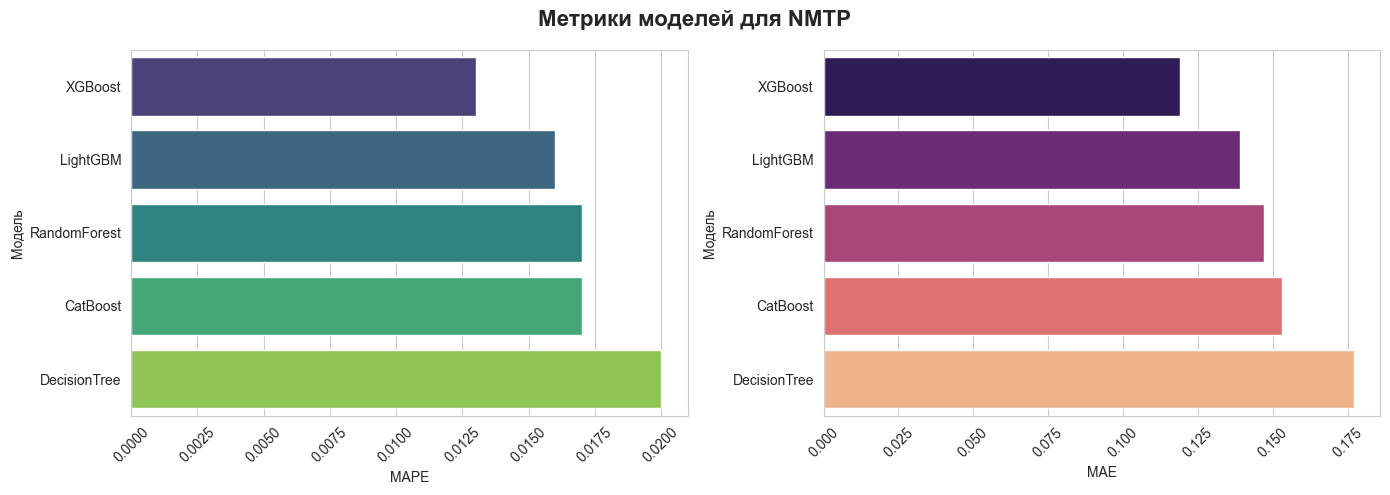

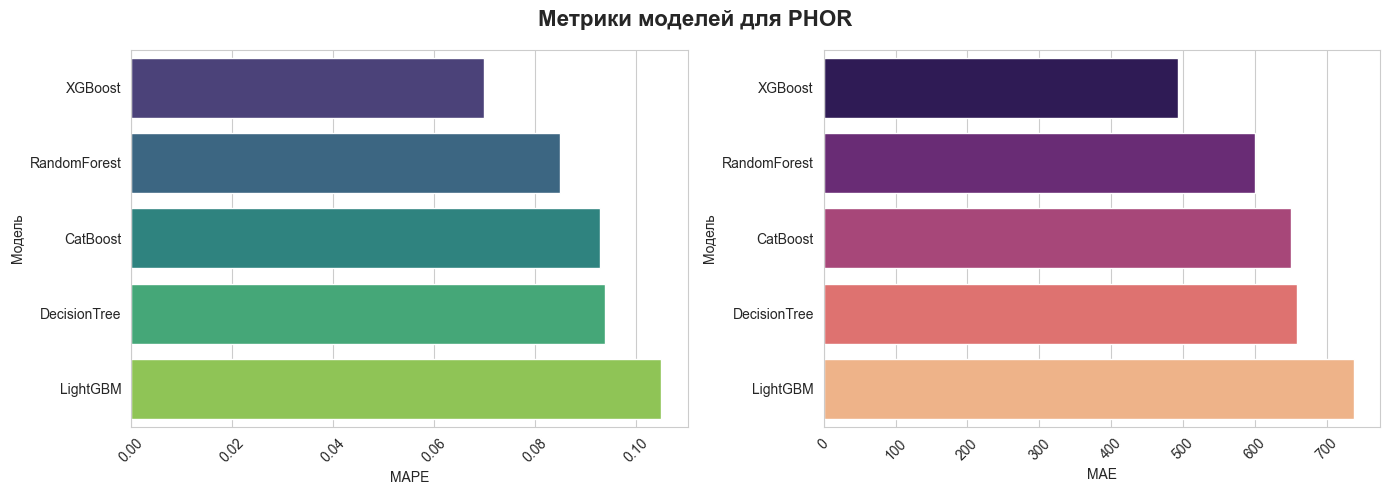

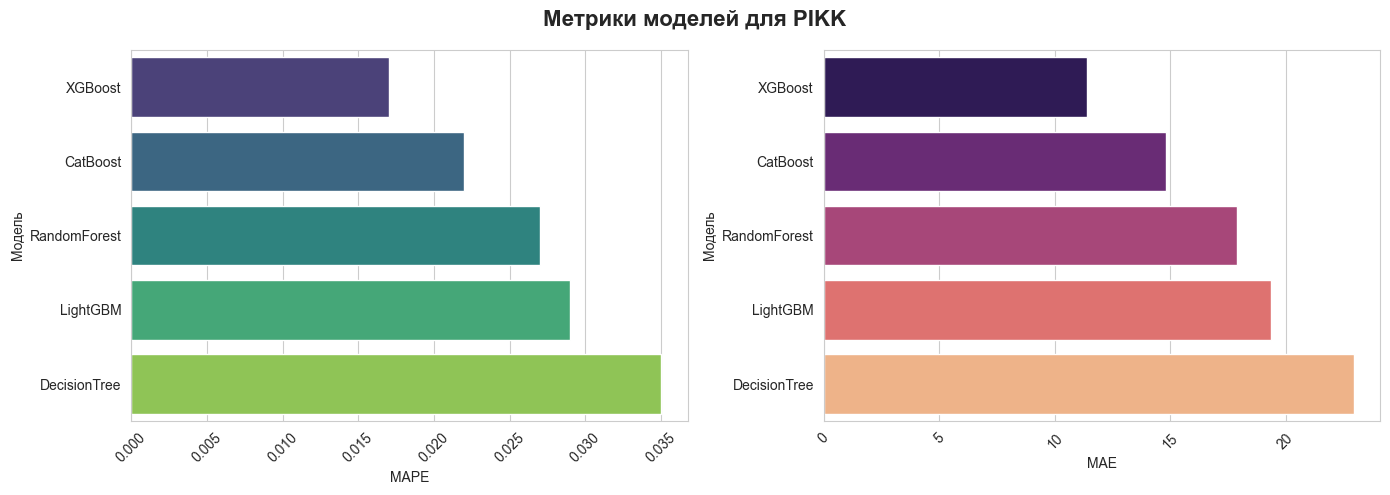

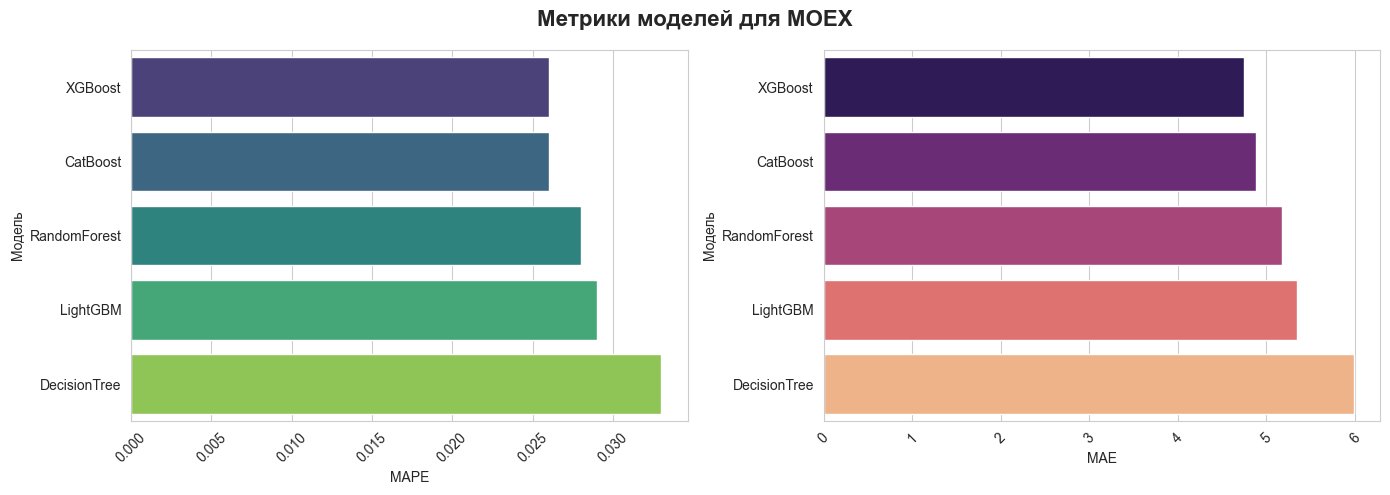

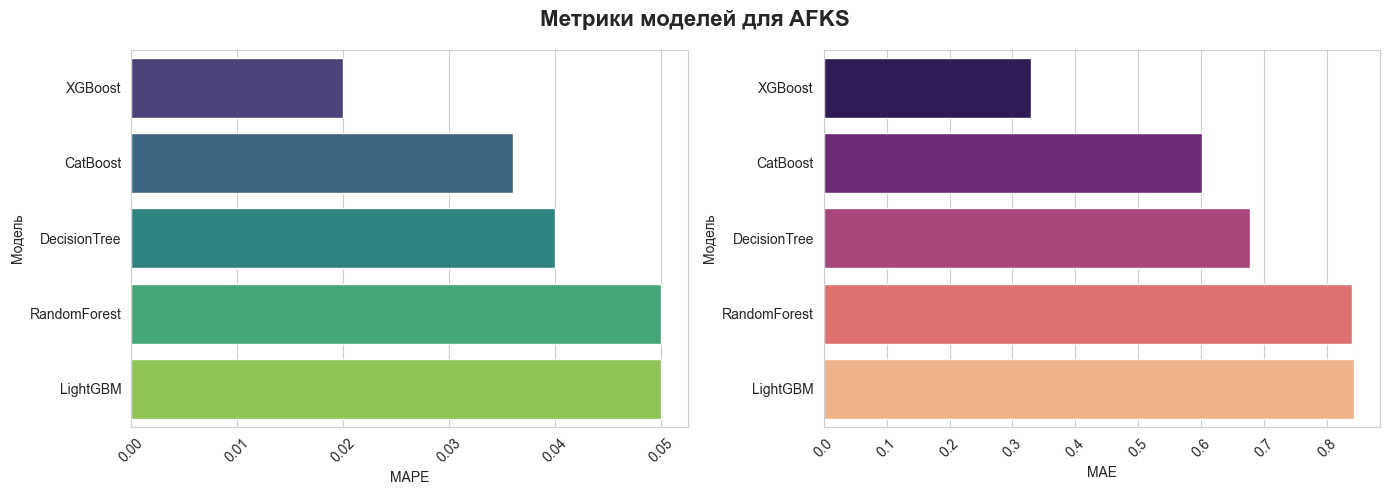

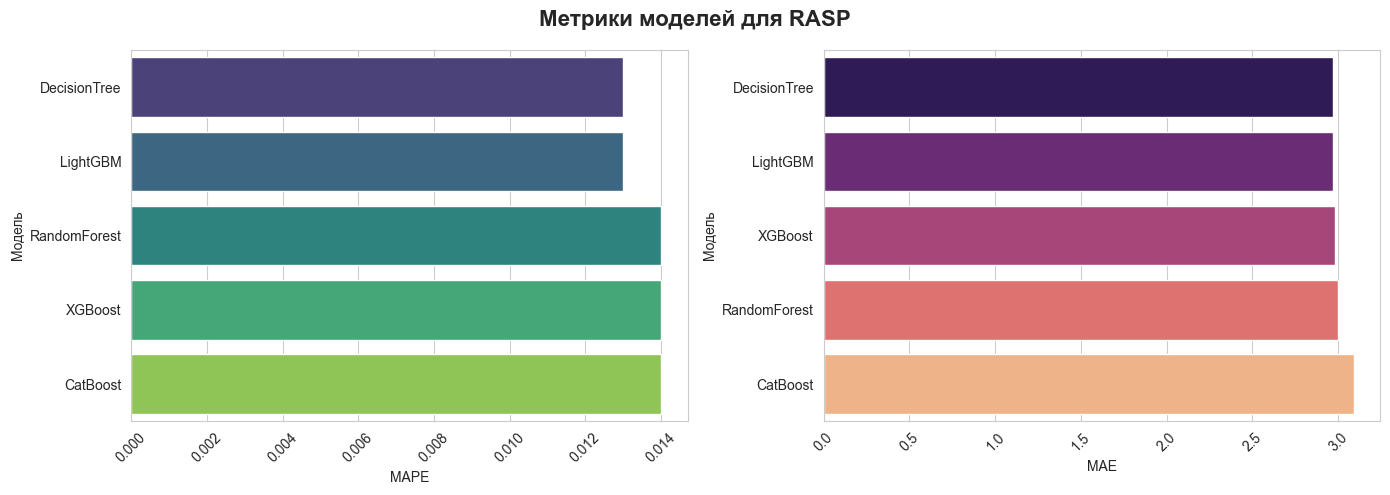

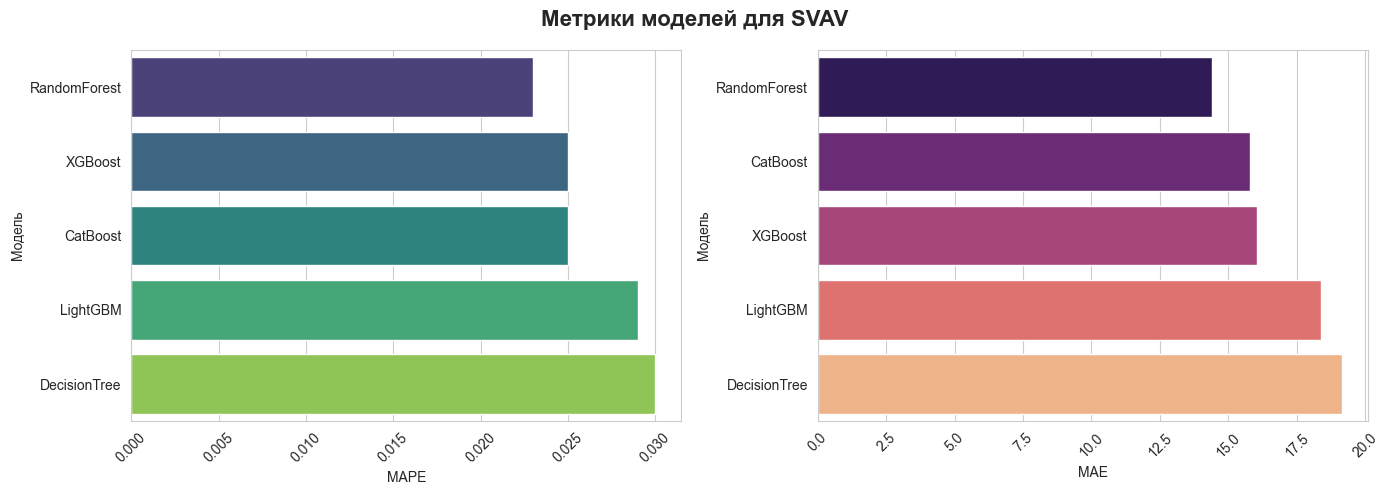

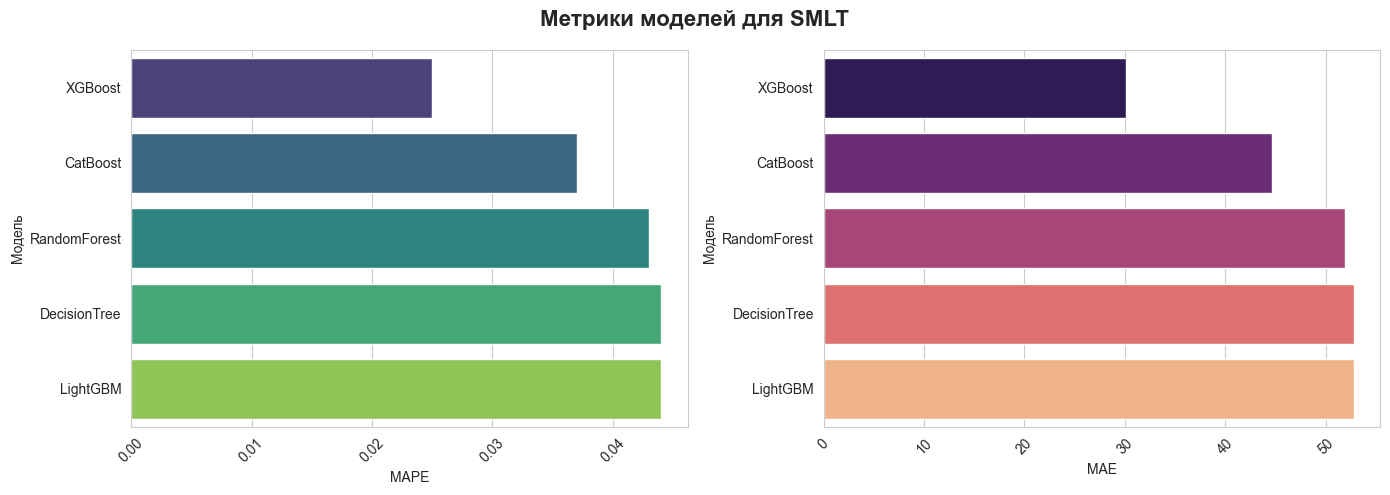

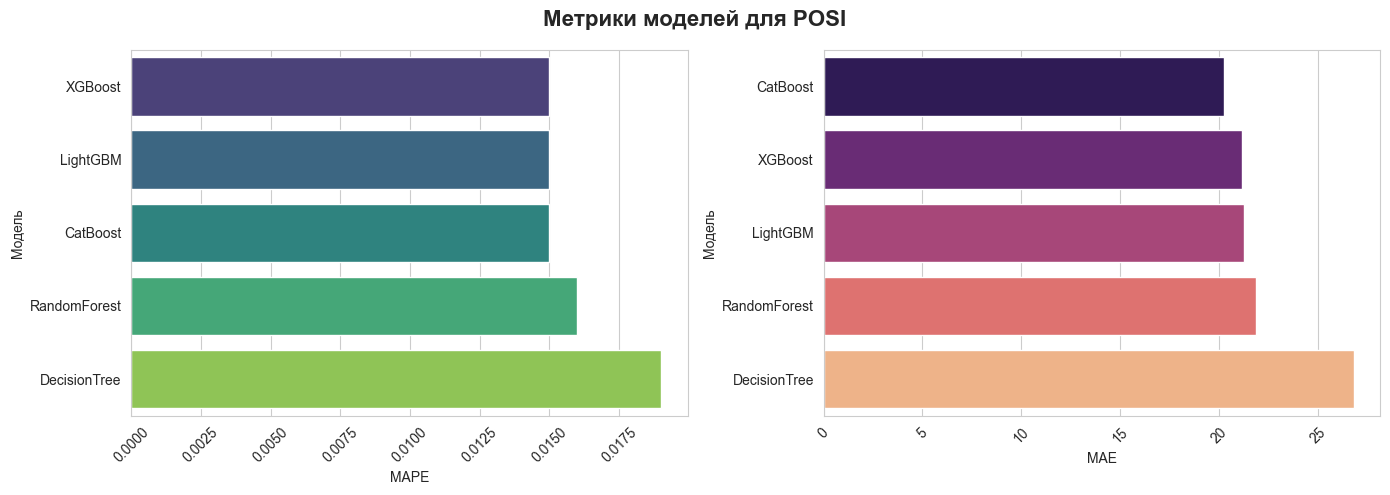

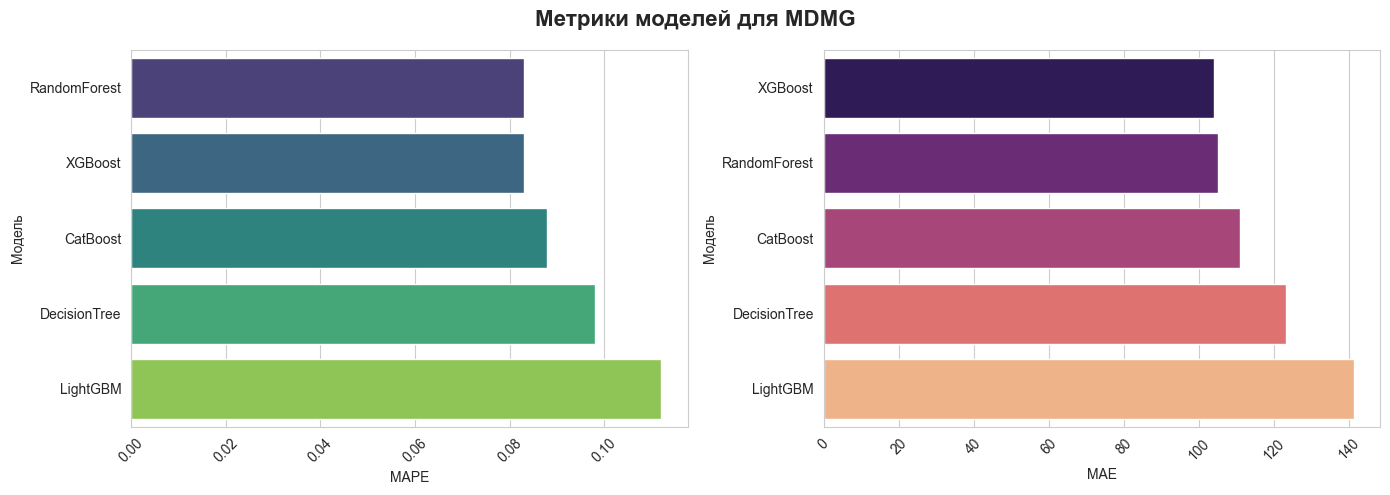

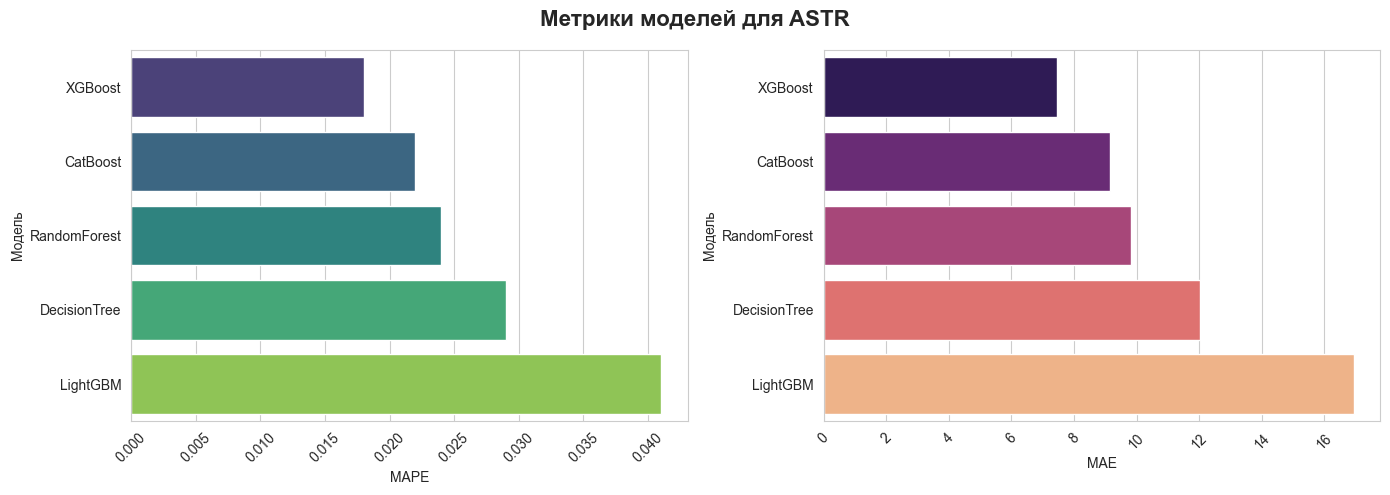

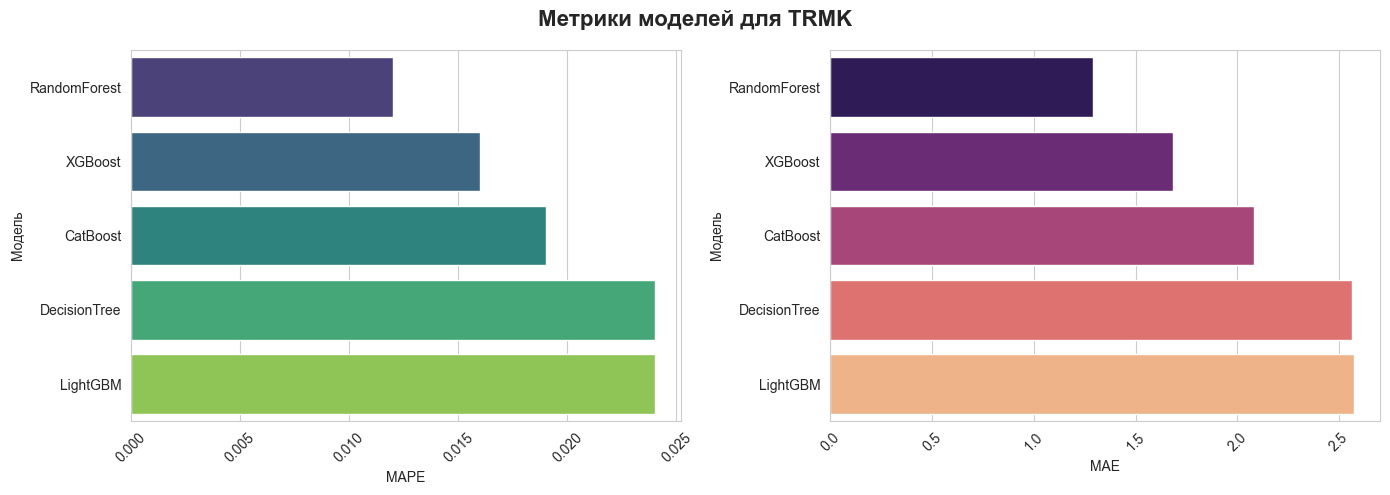

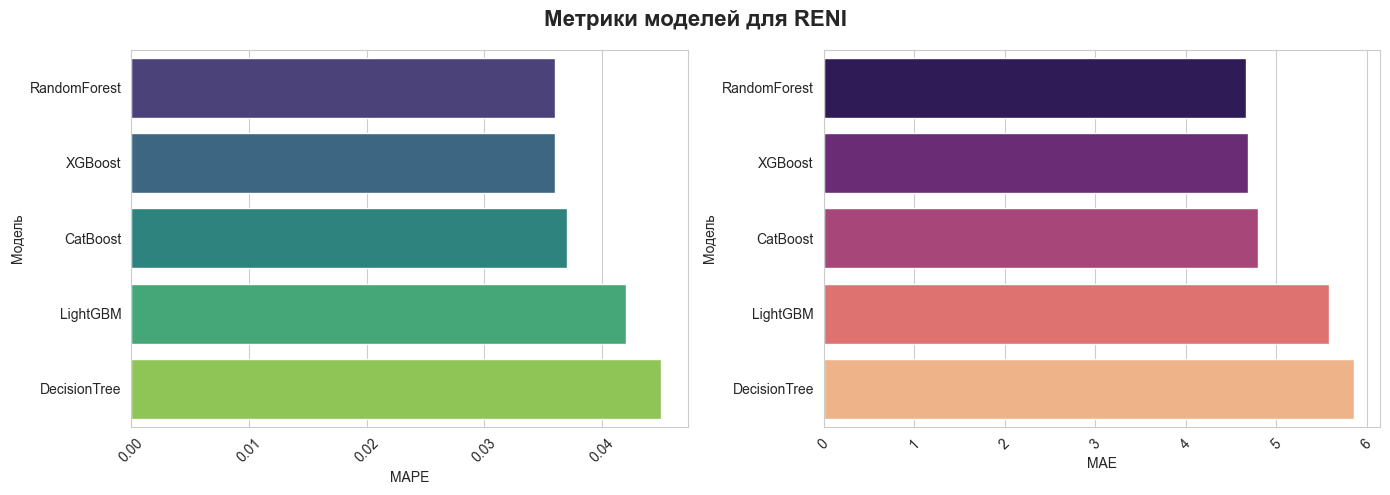

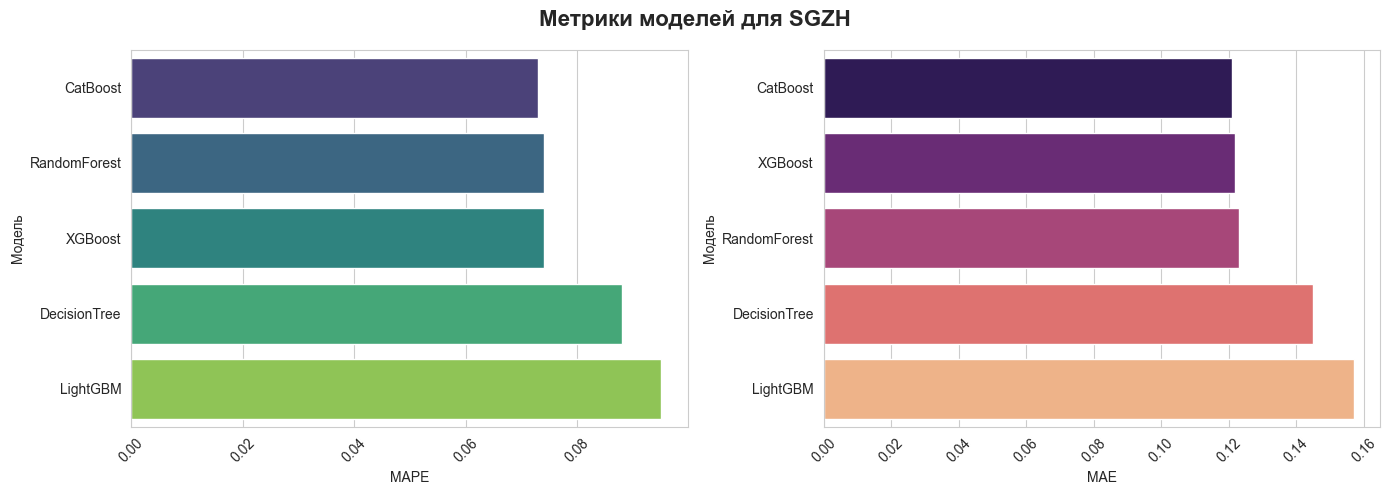

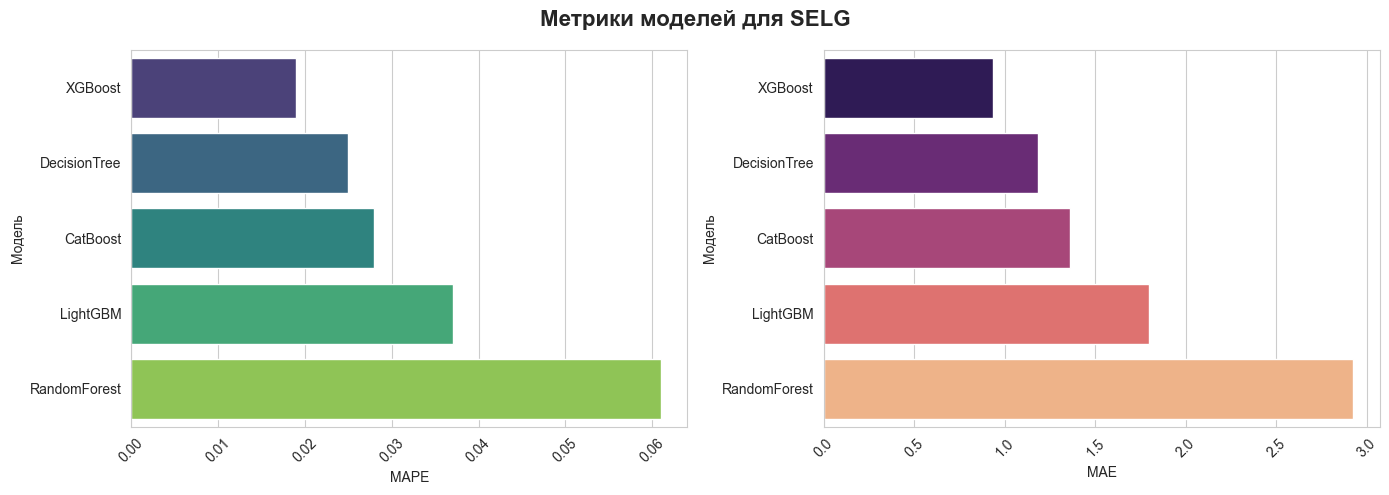

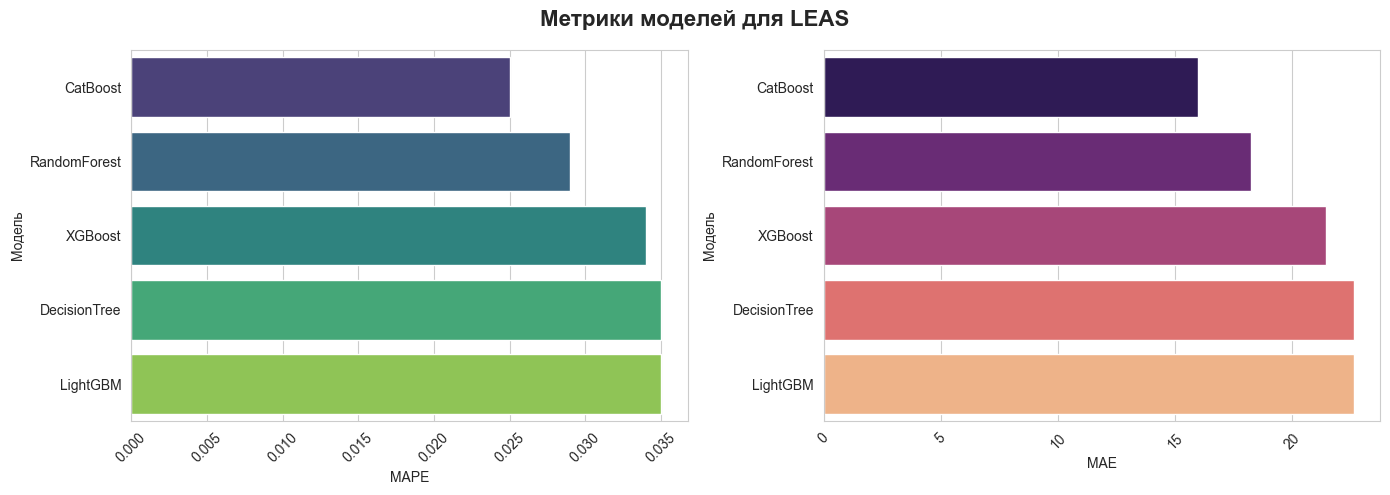

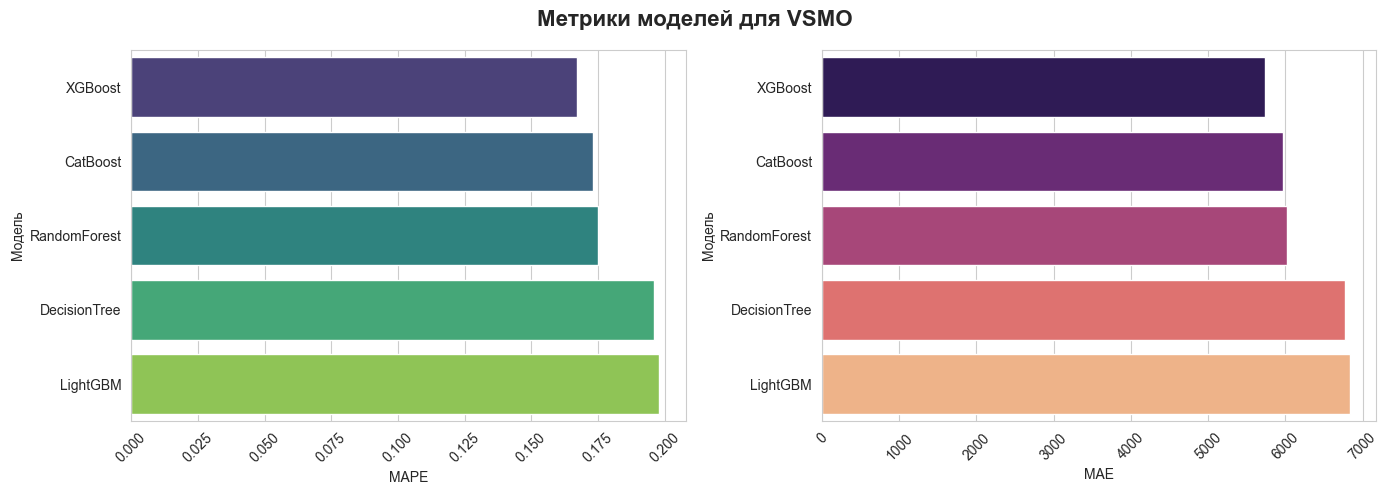

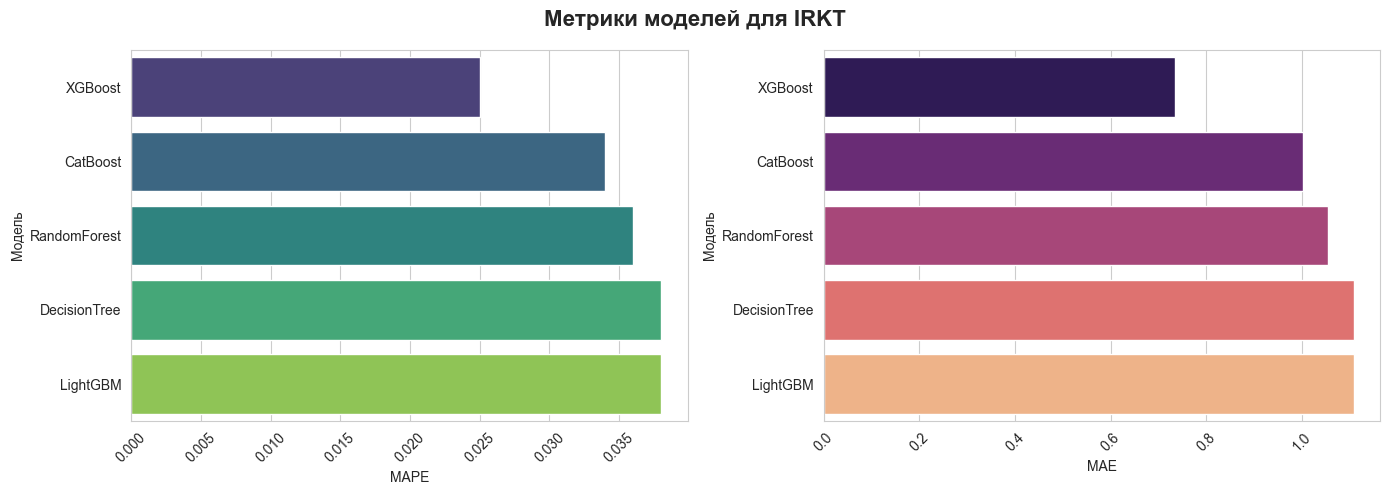

In [ ]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

for ticker in tickers:
    ticker_data = ml_models_data_2025[ml_models_data_2025['ticker'] == ticker].copy()
    plot_data = ticker_data[['model_name', 'model_value', 'mape_mean', 'mae_mean']].dropna()
    
    if plot_data.empty:
        continue
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Метрики моделей для {ticker}', fontsize=16, fontweight='bold')
    
    sns.barplot(
        data=plot_data.sort_values('mape_mean'),
        x='mape_mean', 
        y='model_name', 
        ax=axes[0],
        palette='viridis',
        hue='model_value',
        legend=False
    )
    axes[0].set_xlabel('MAPE')
    axes[0].set_ylabel('Модель')
    axes[0].tick_params(axis='x', rotation=45)
    
    sns.barplot(
        data=plot_data.sort_values('mae_mean'),
        x='mae_mean', 
        y='model_name', 
        ax=axes[1],
        palette='magma',
        hue='model_value',
        legend=False
    )
    axes[1].set_xlabel('MAE')
    axes[1].set_ylabel('Модель')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

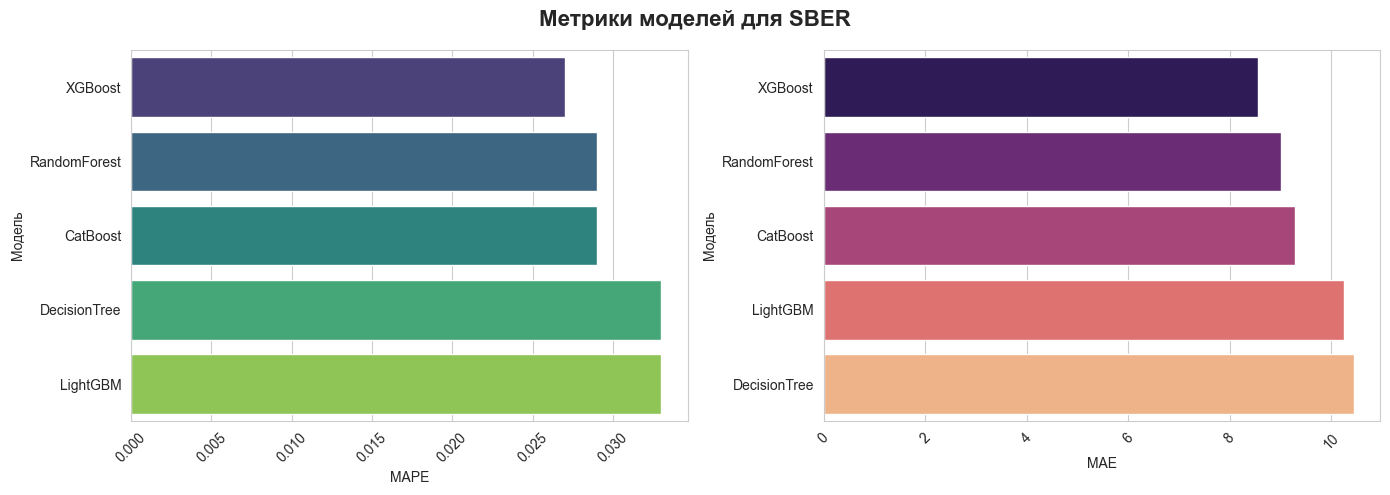

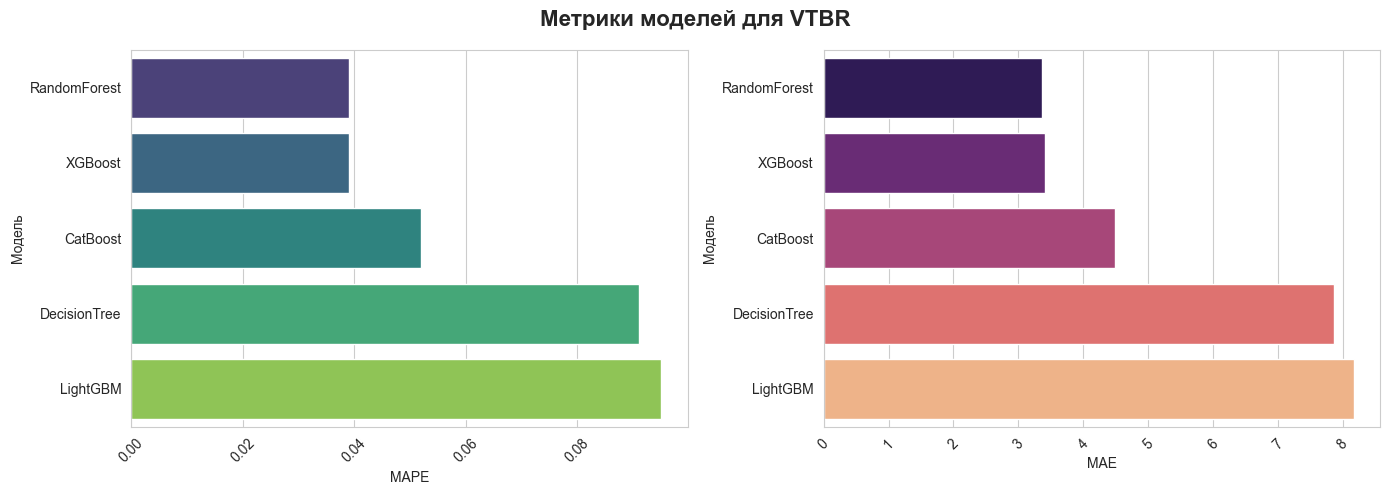

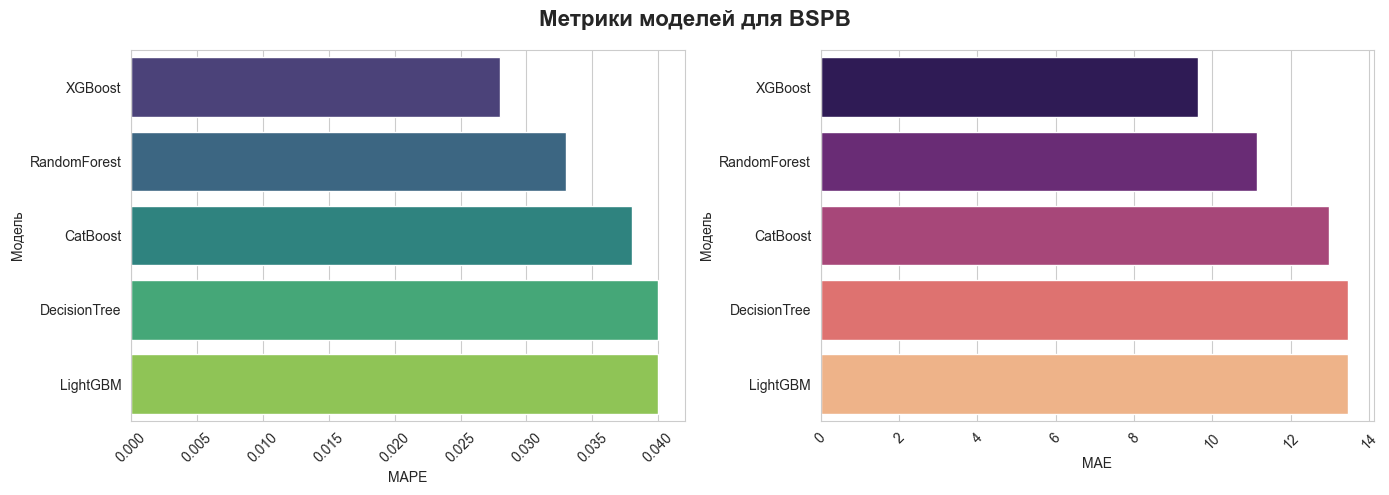

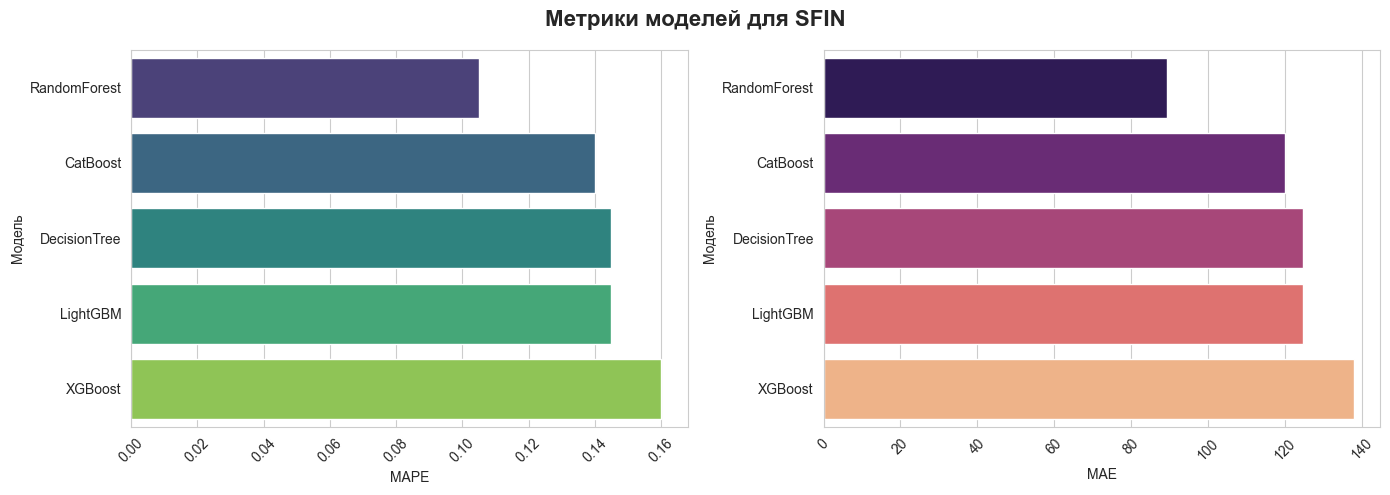

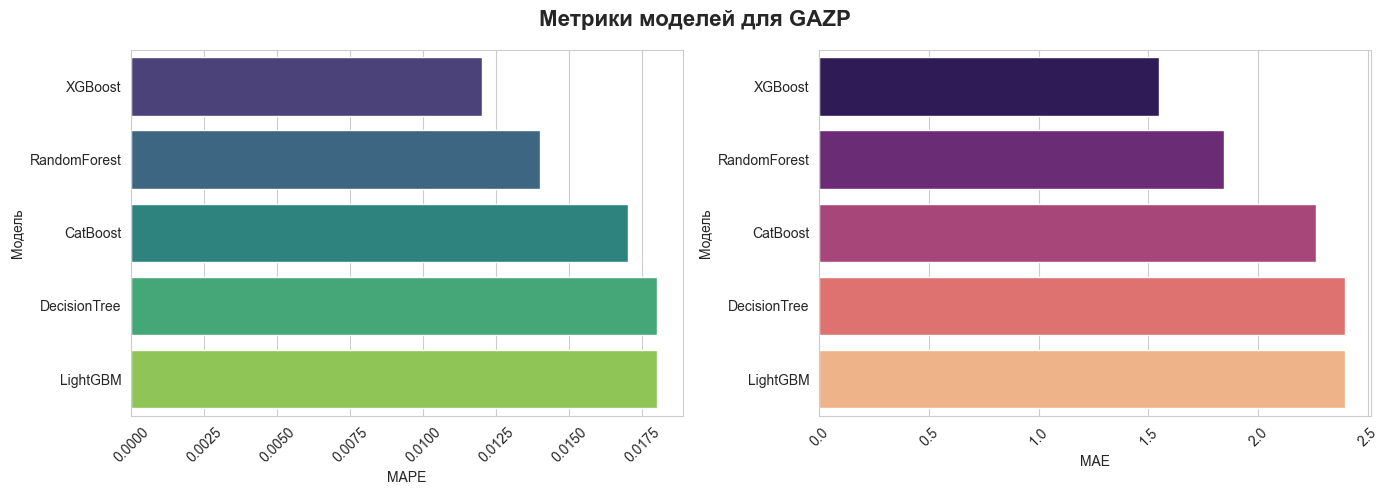

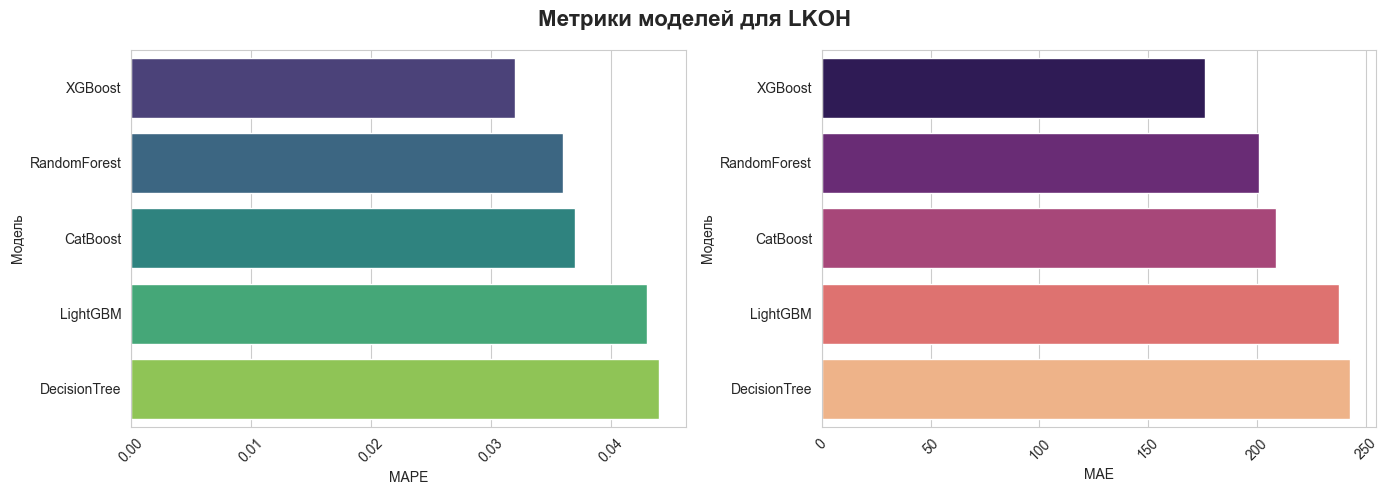

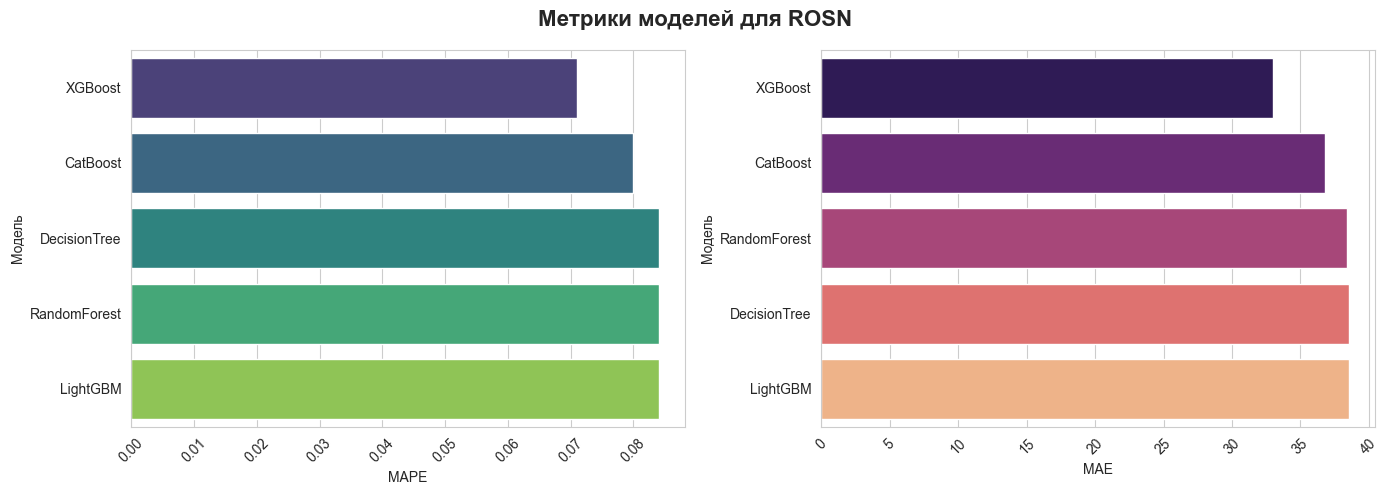

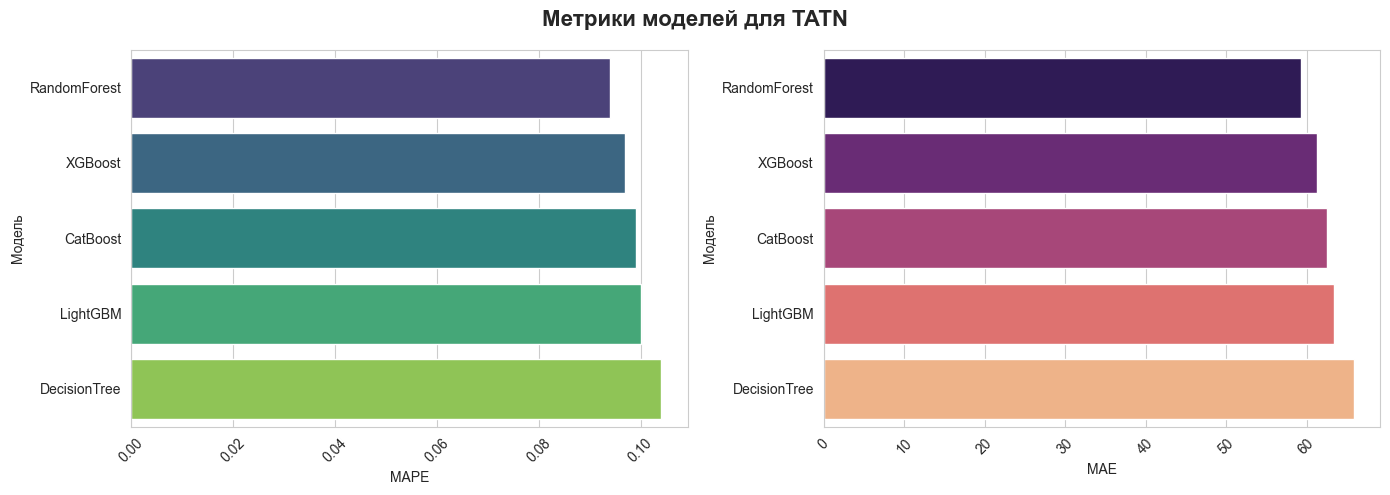

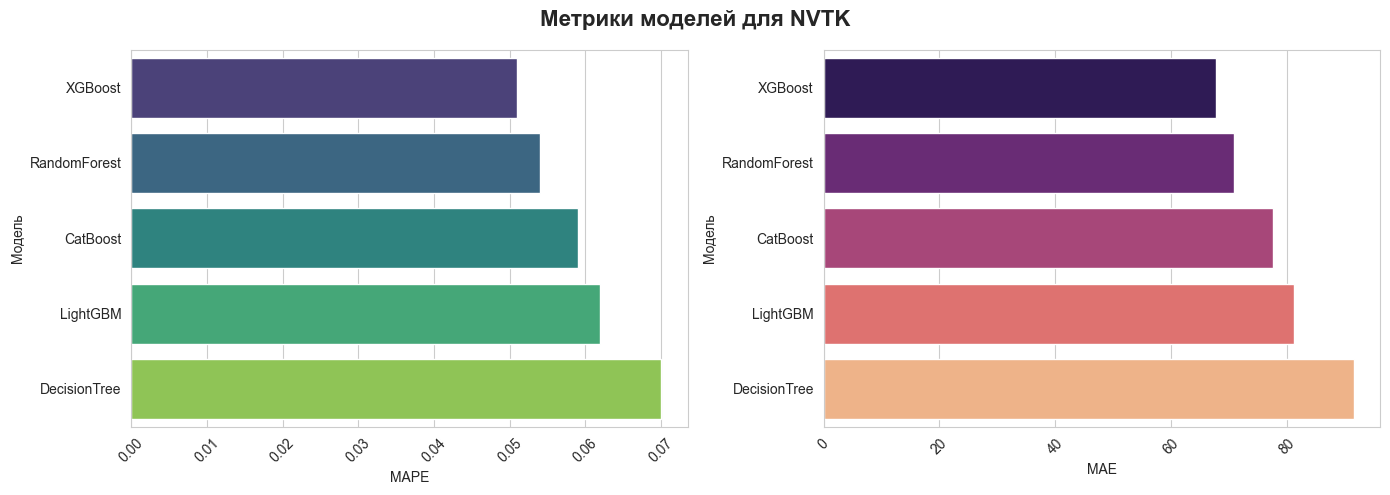

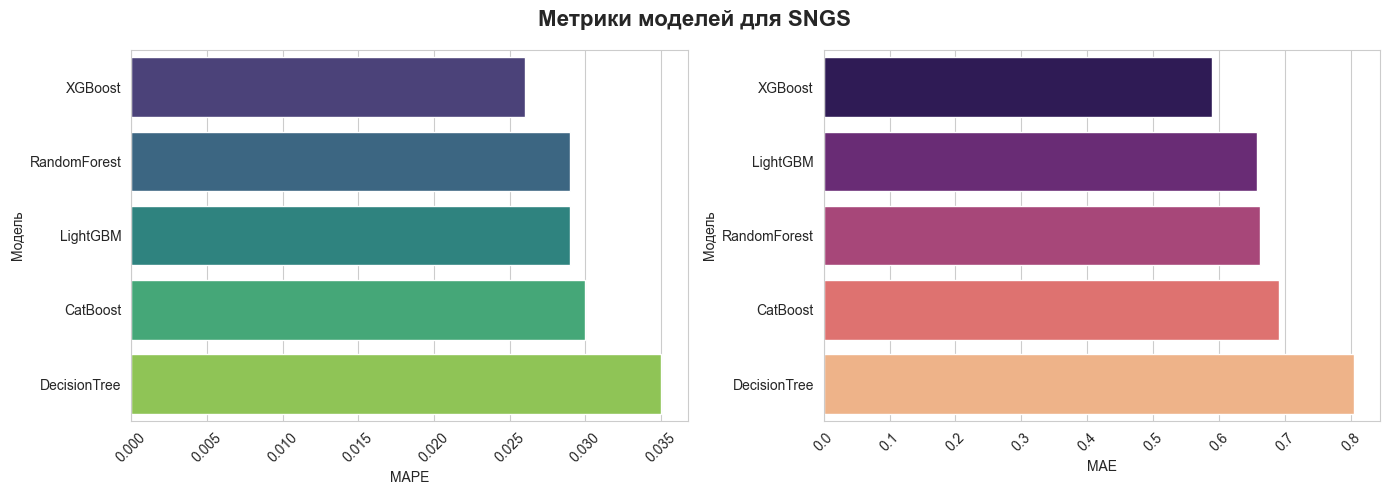

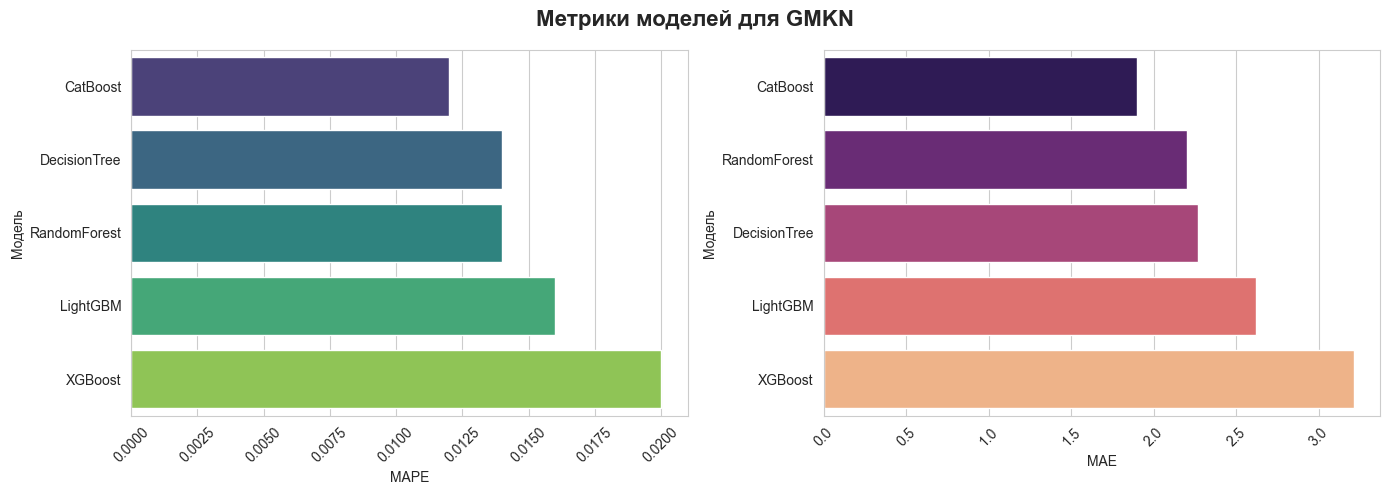

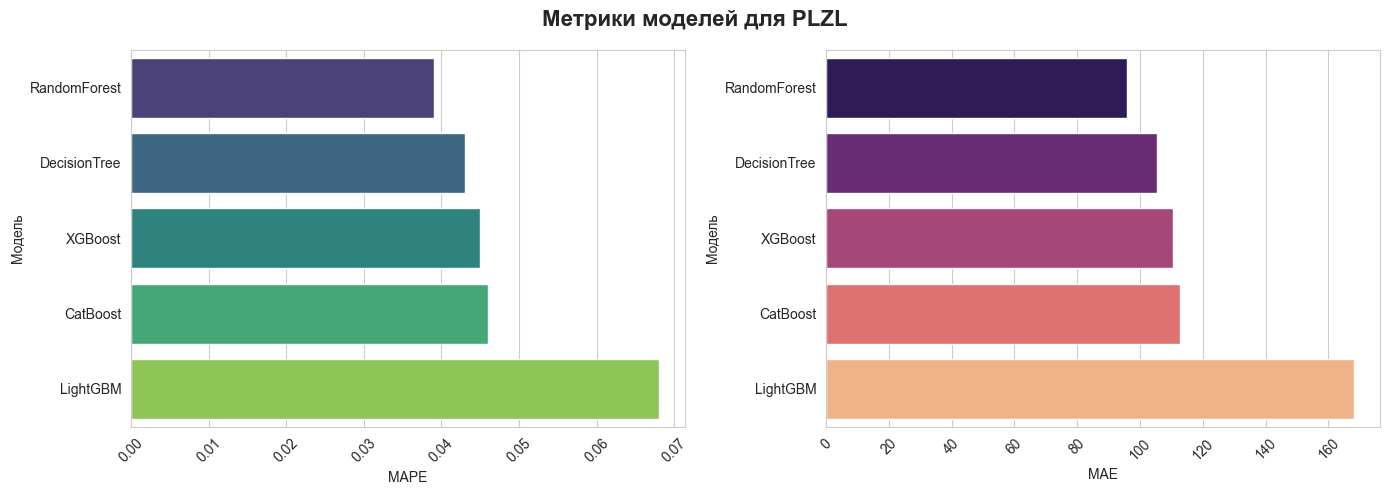

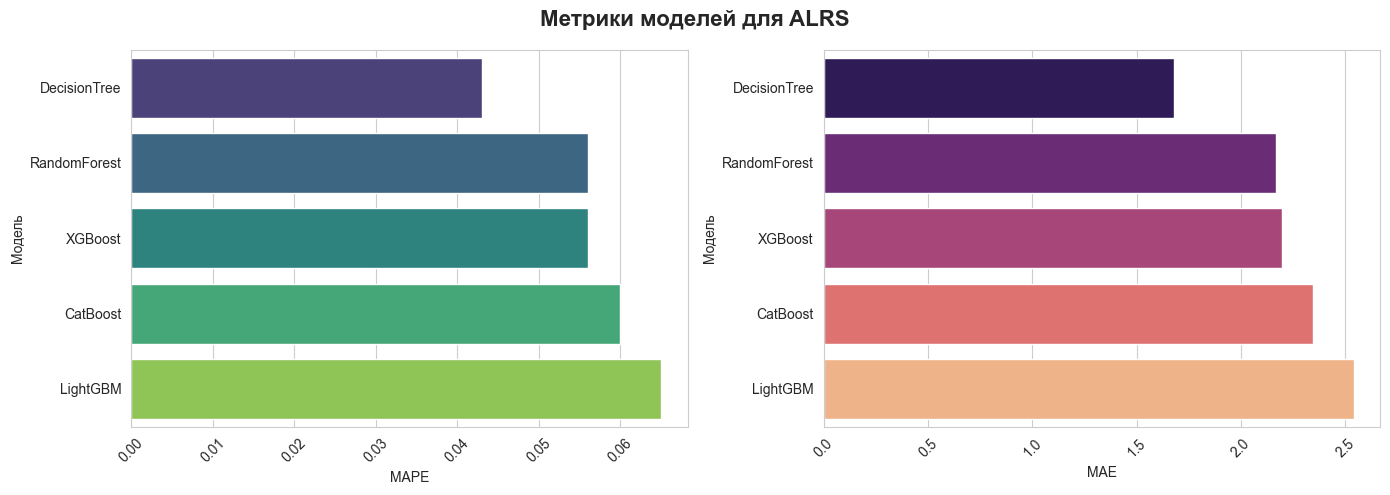

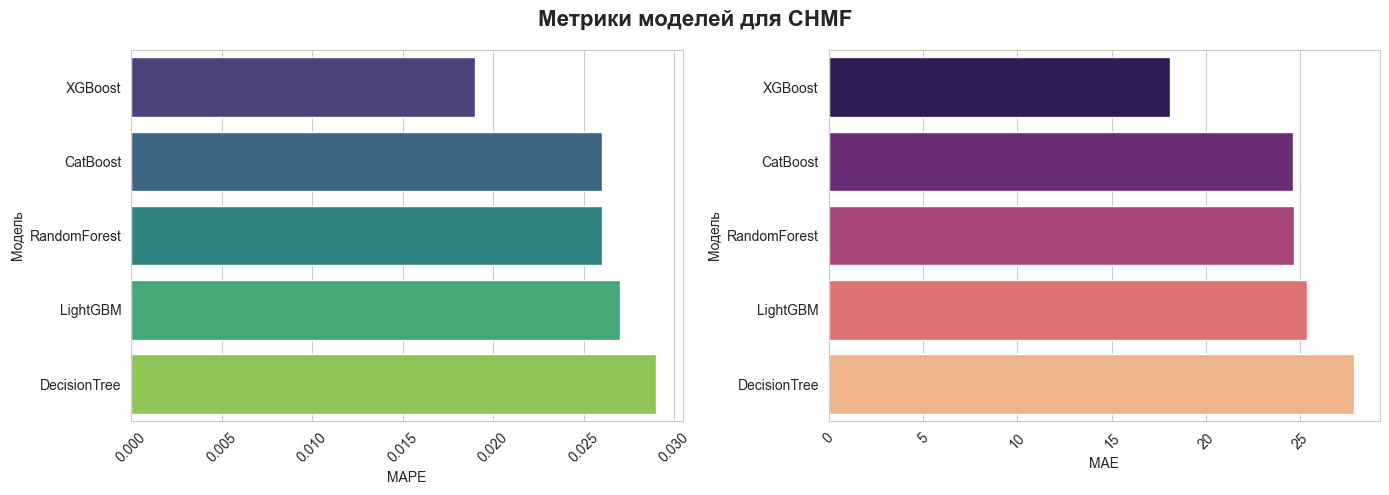

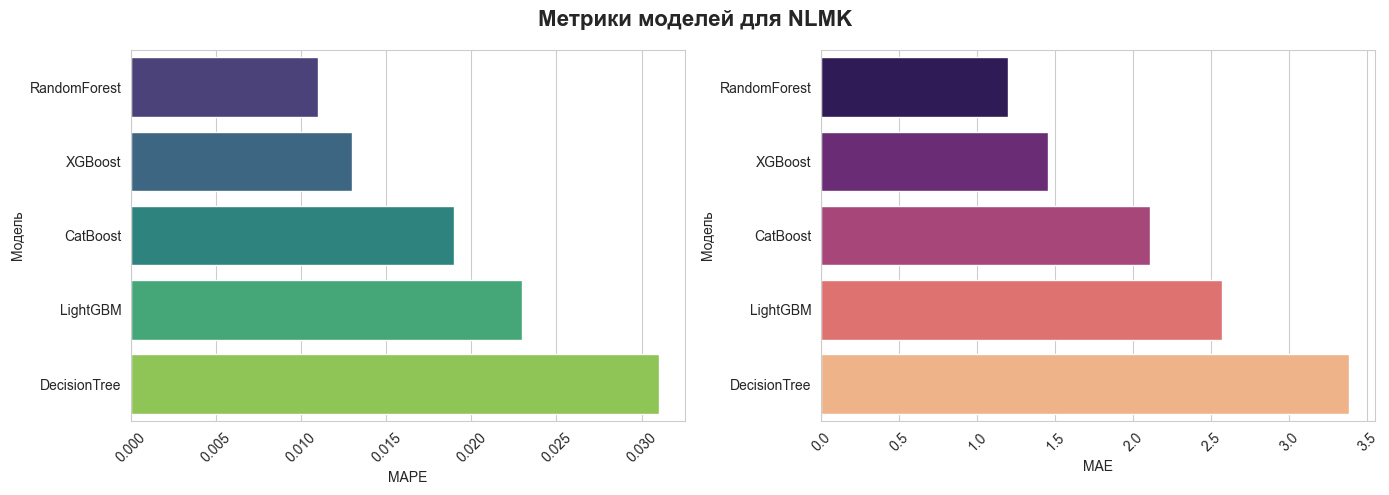

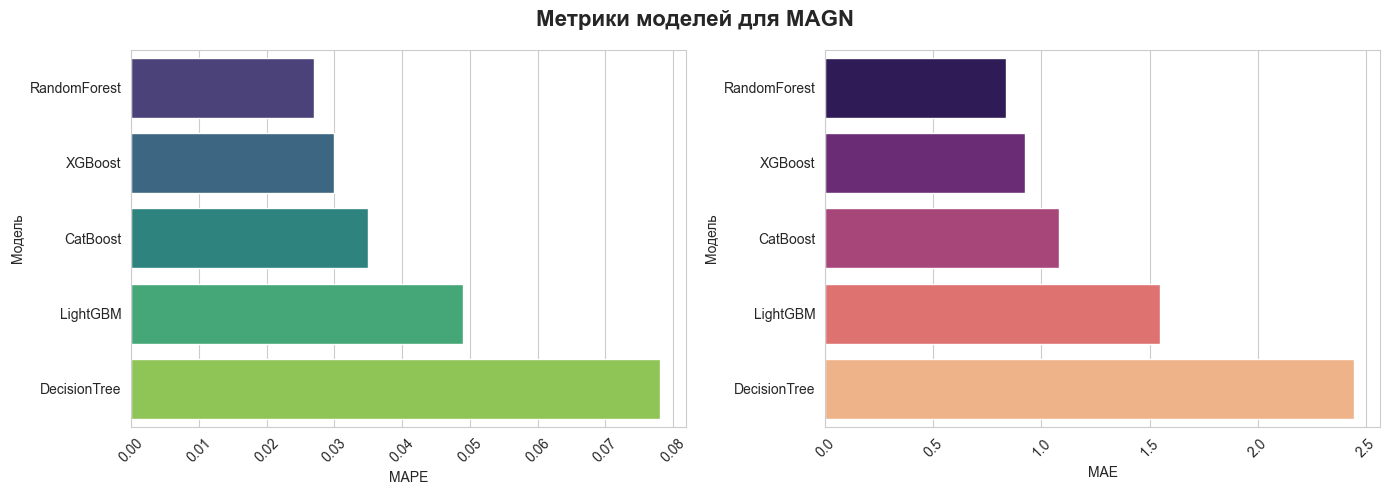

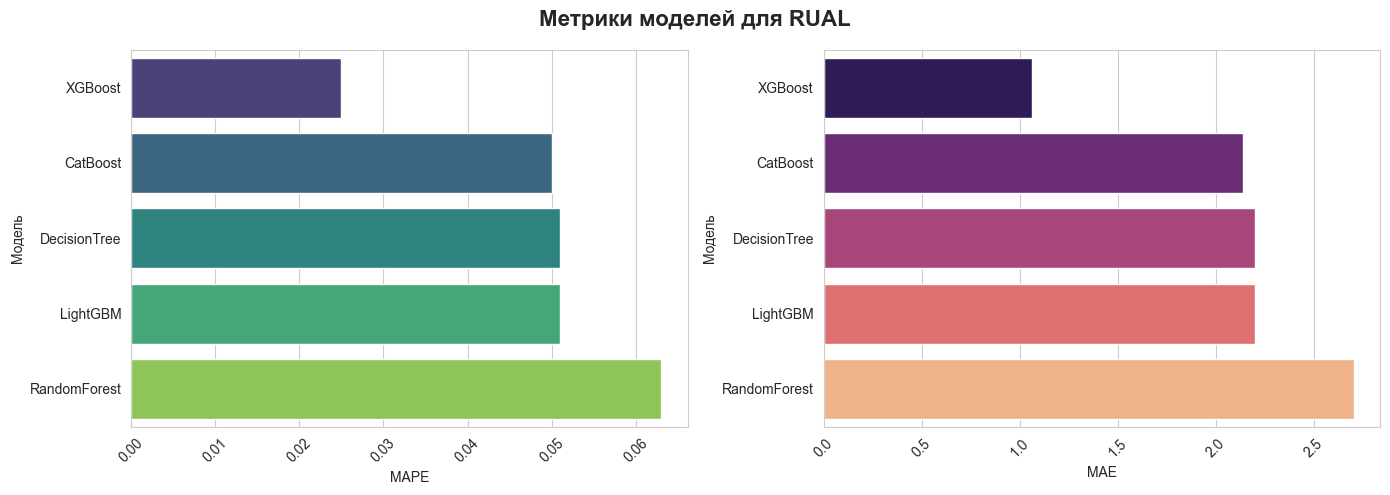

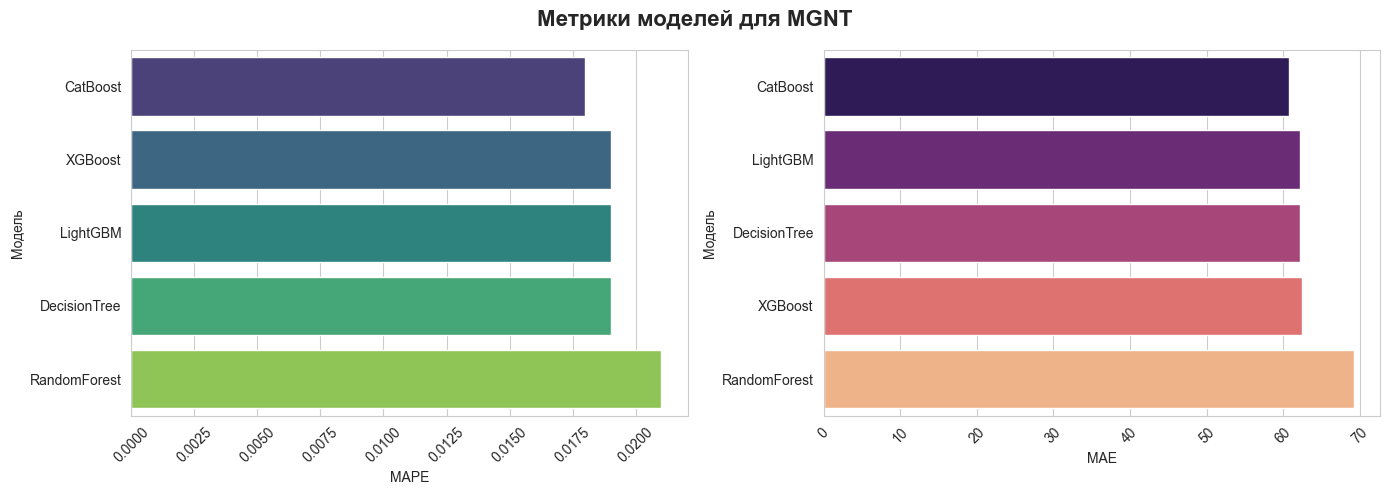

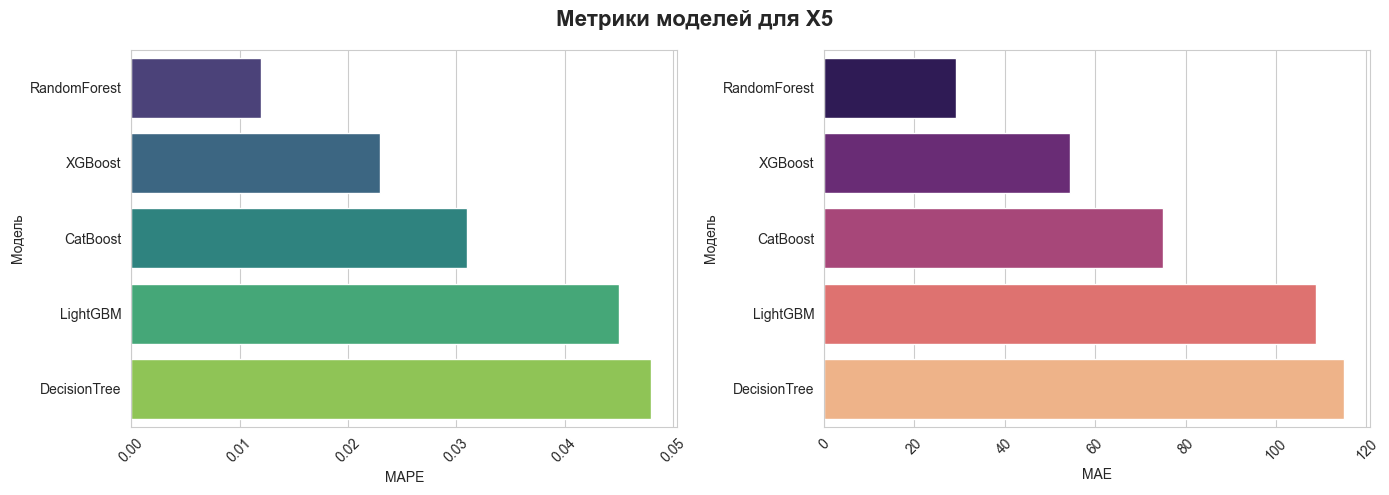

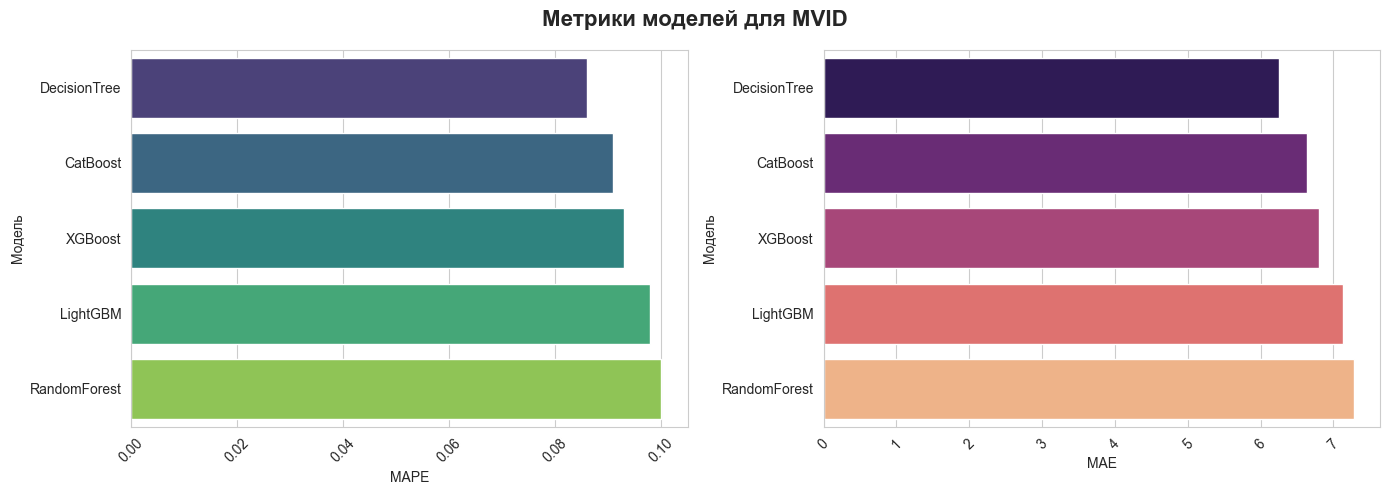

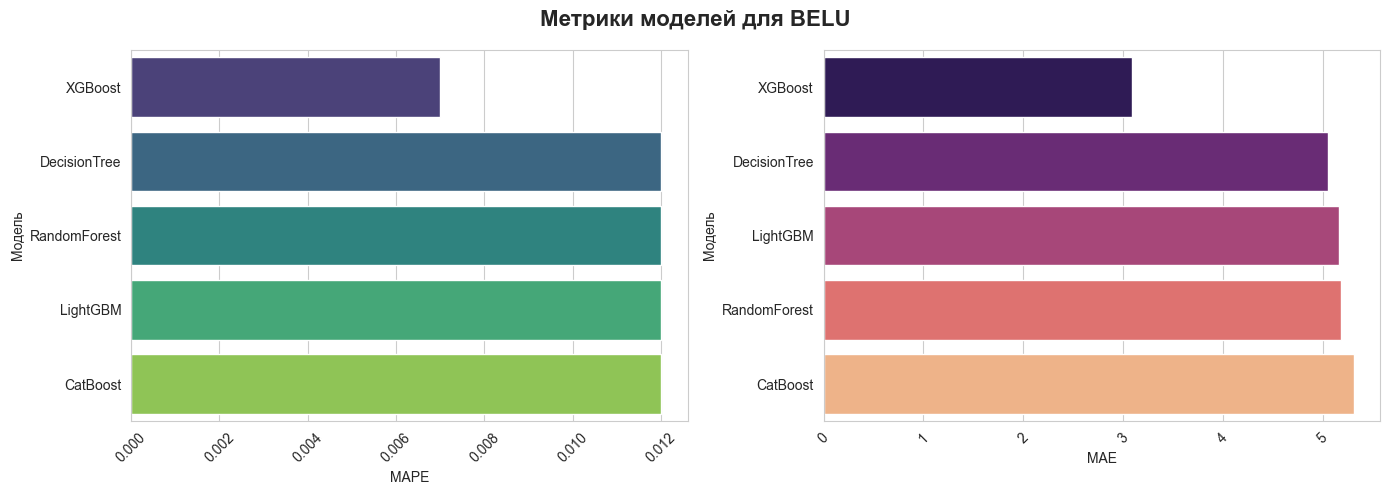

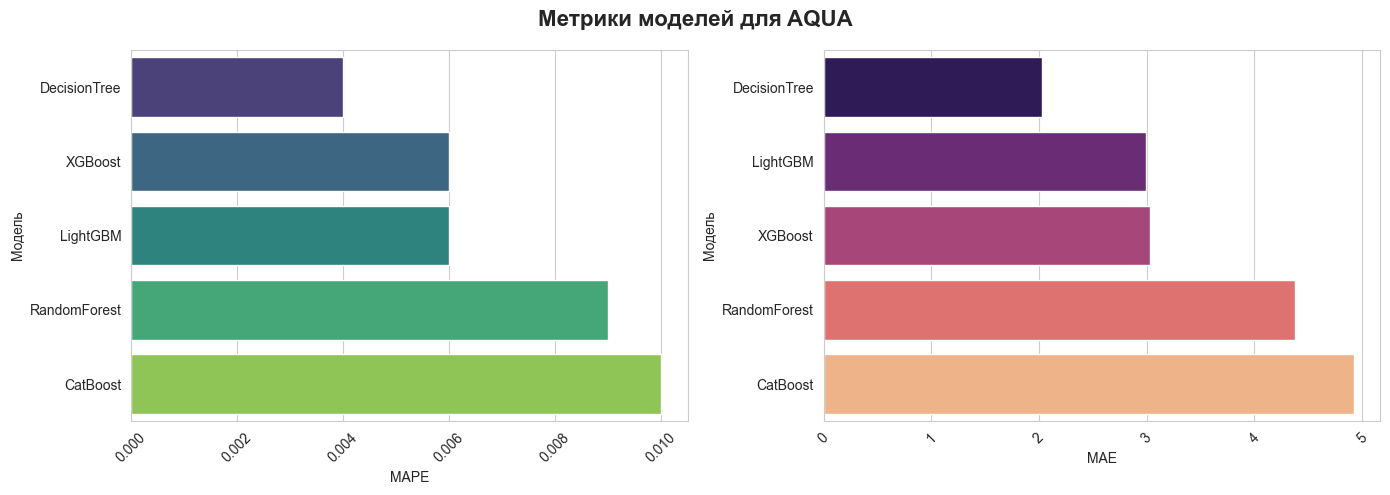

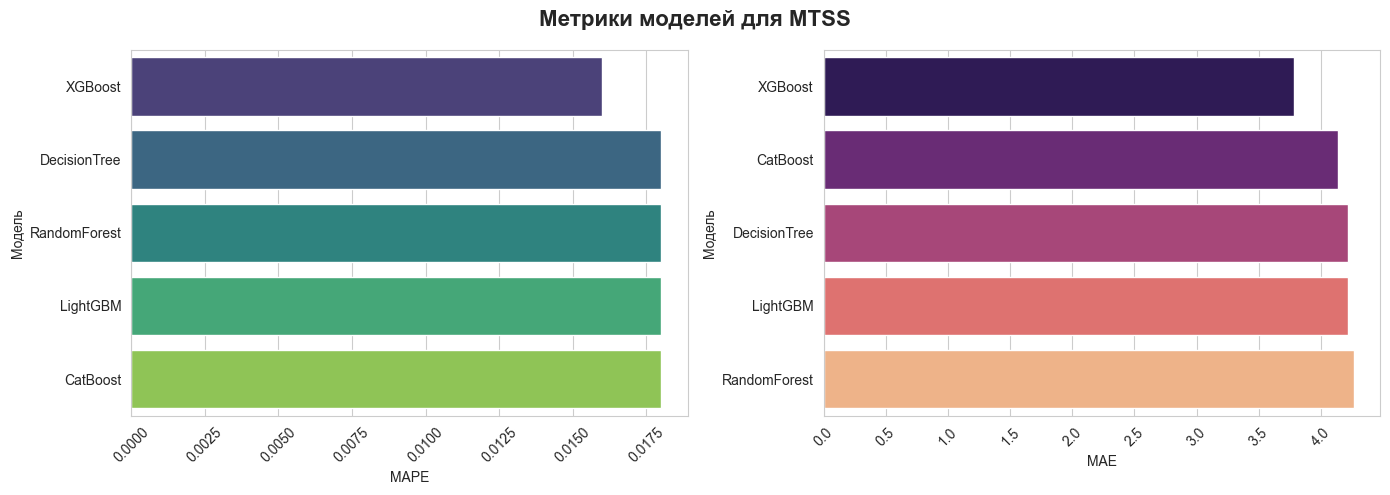

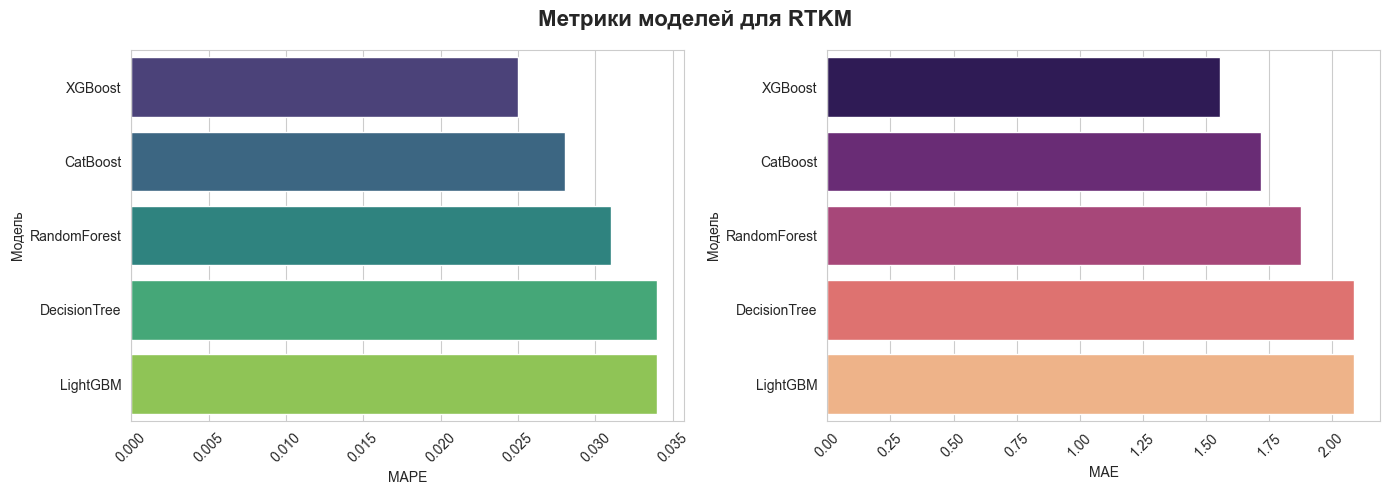

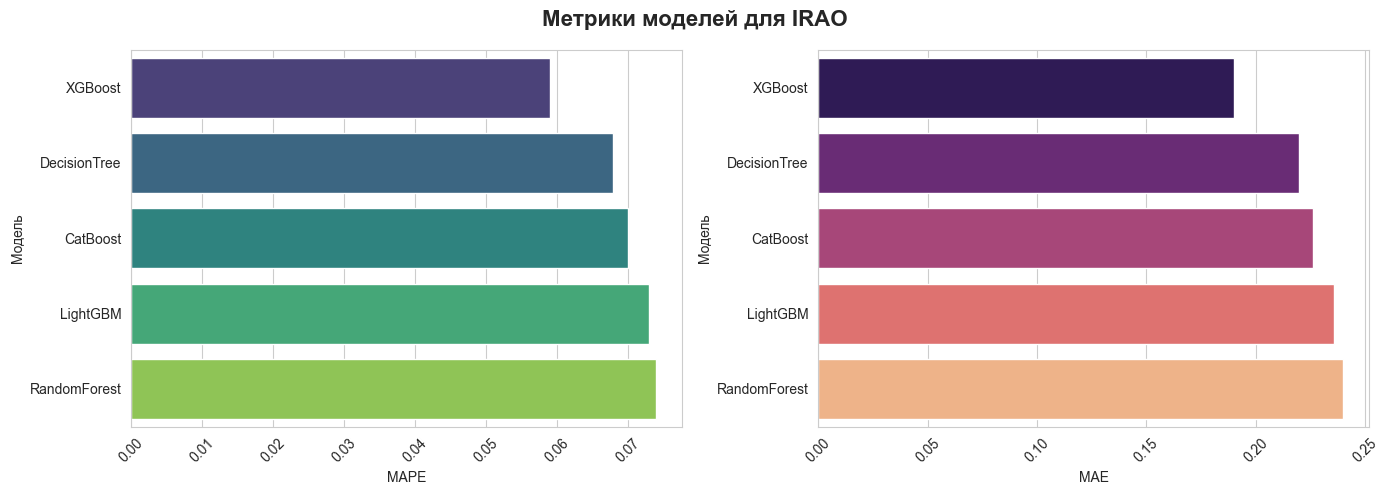

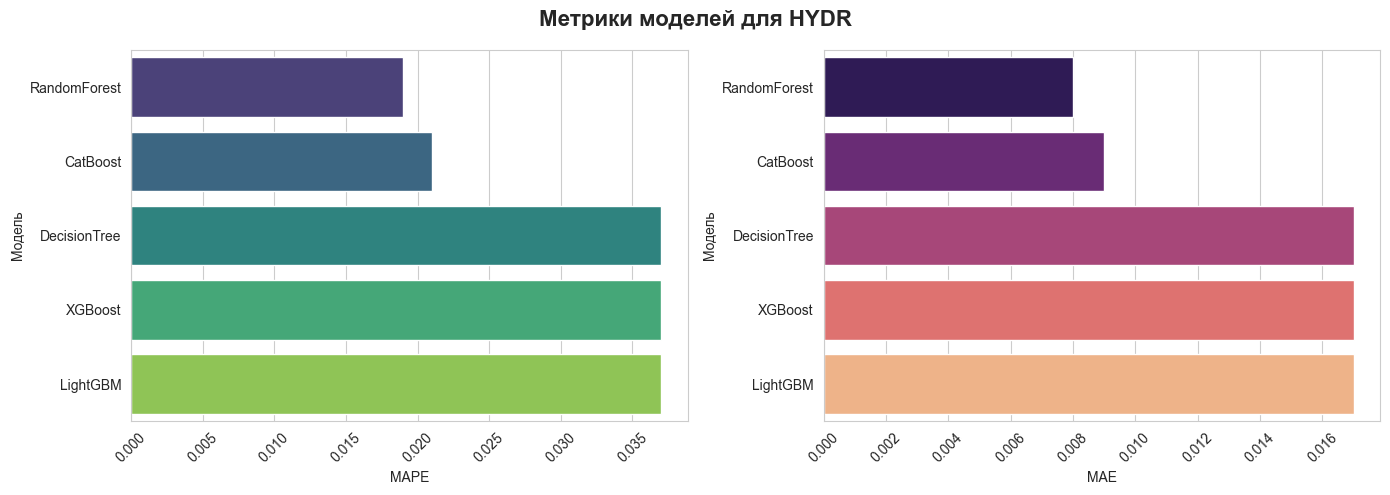

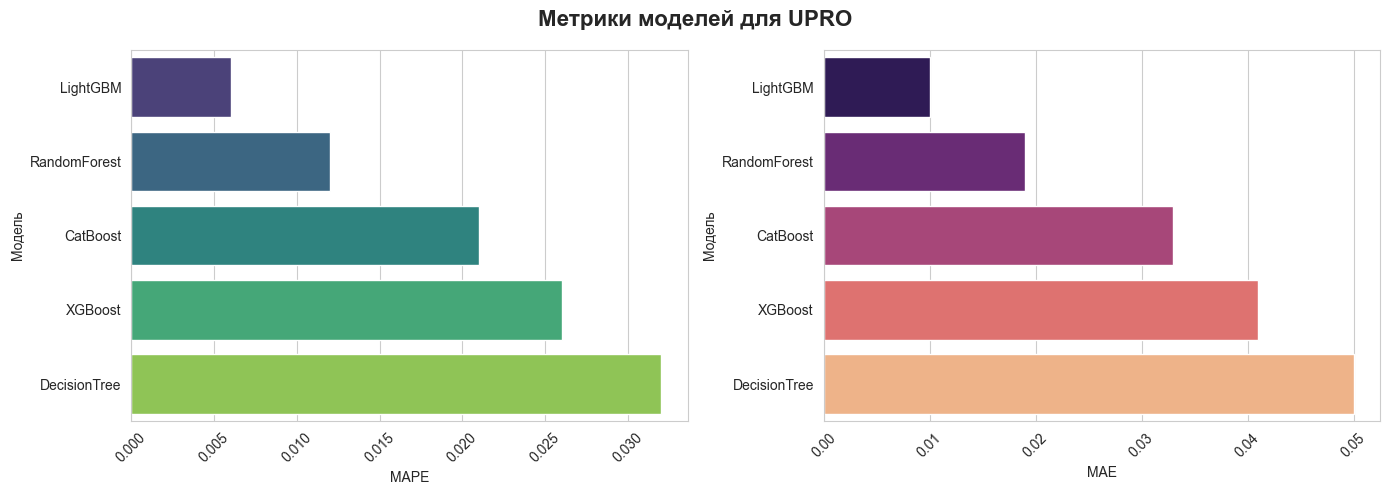

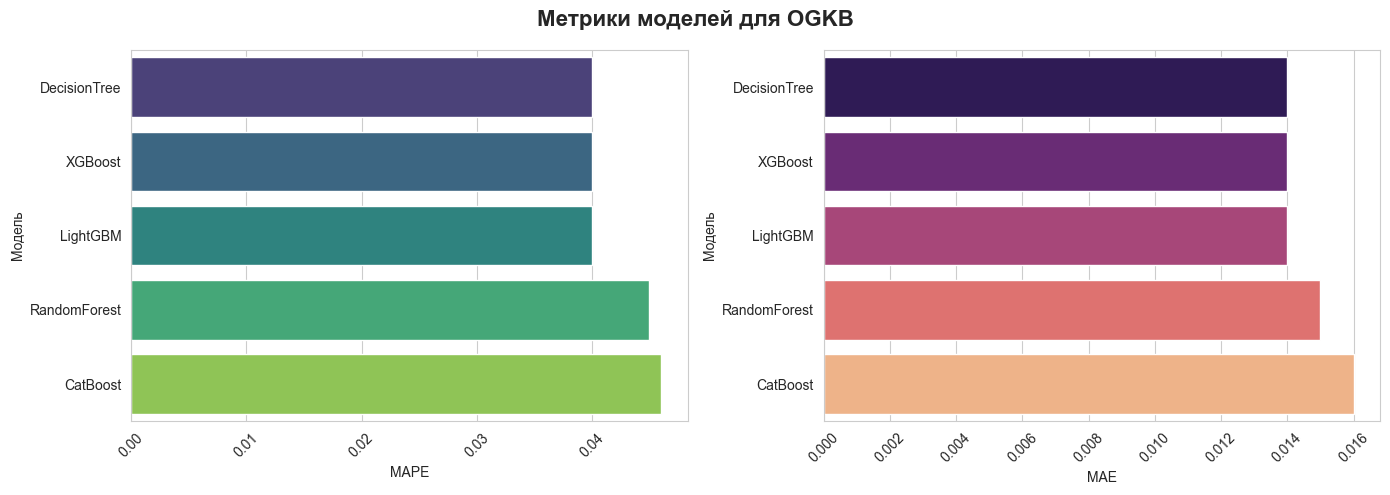

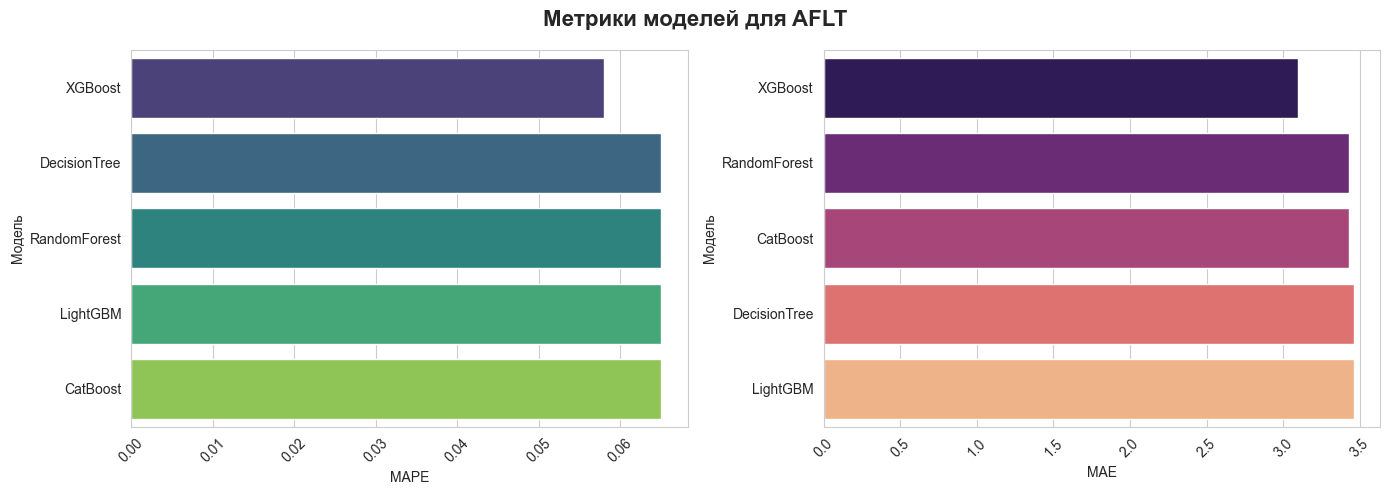

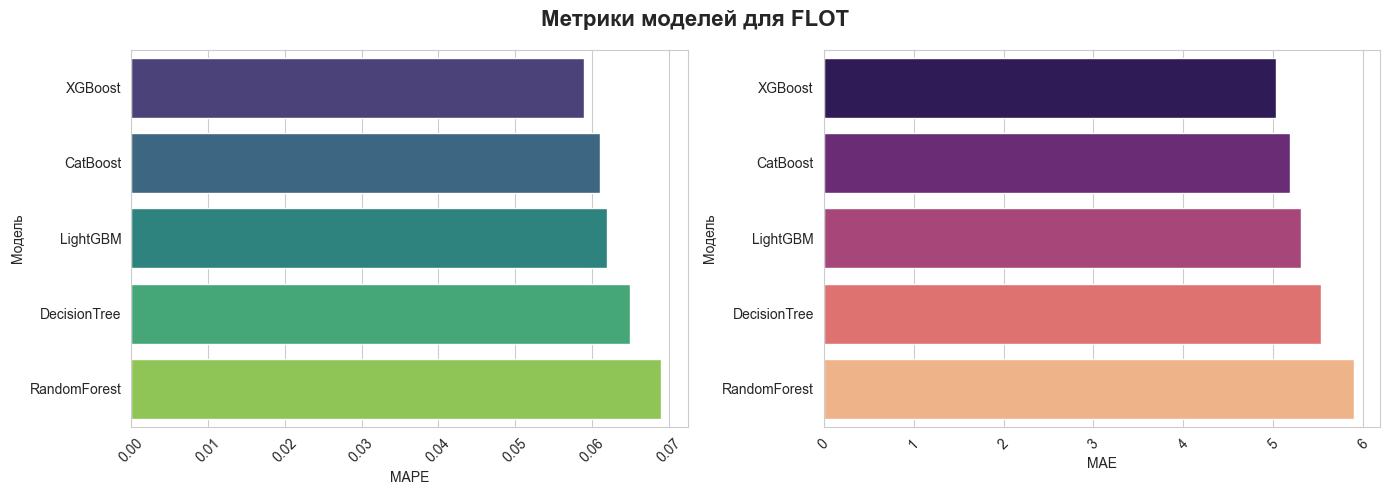

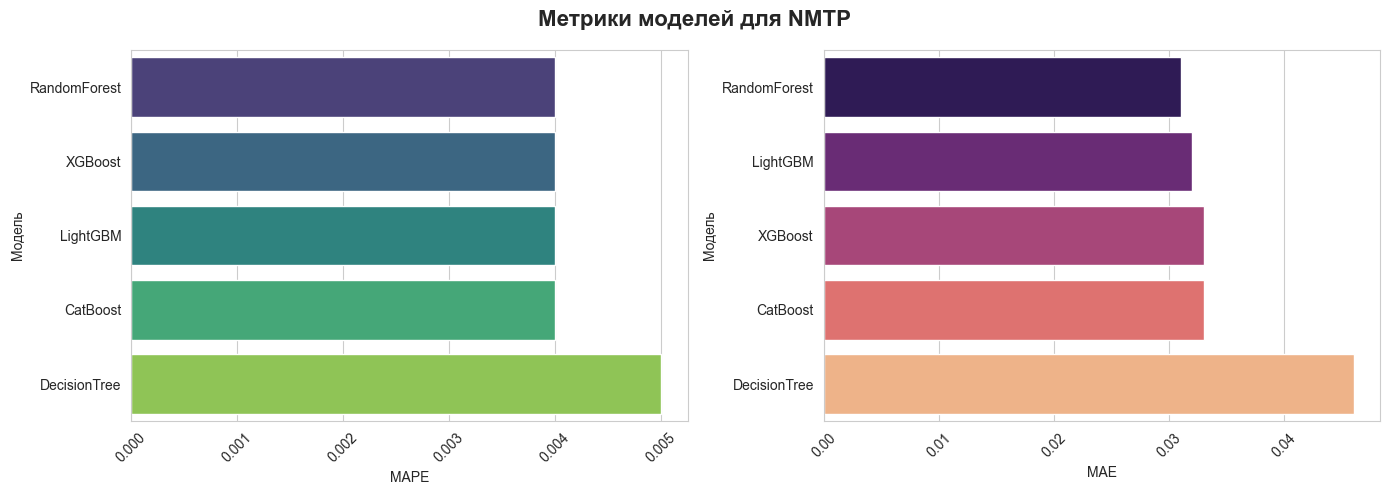

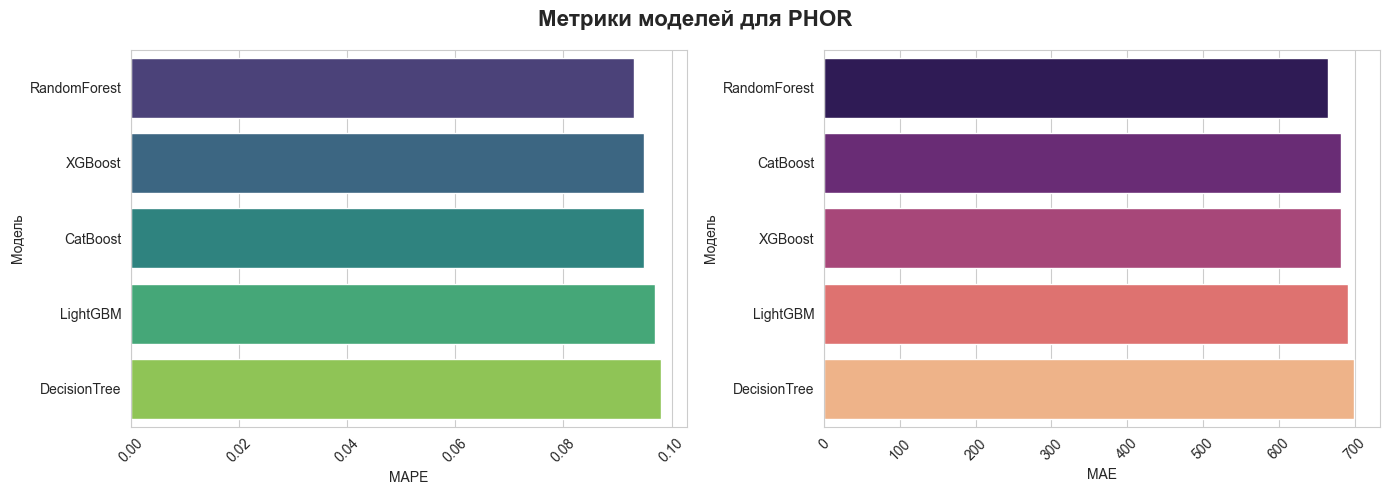

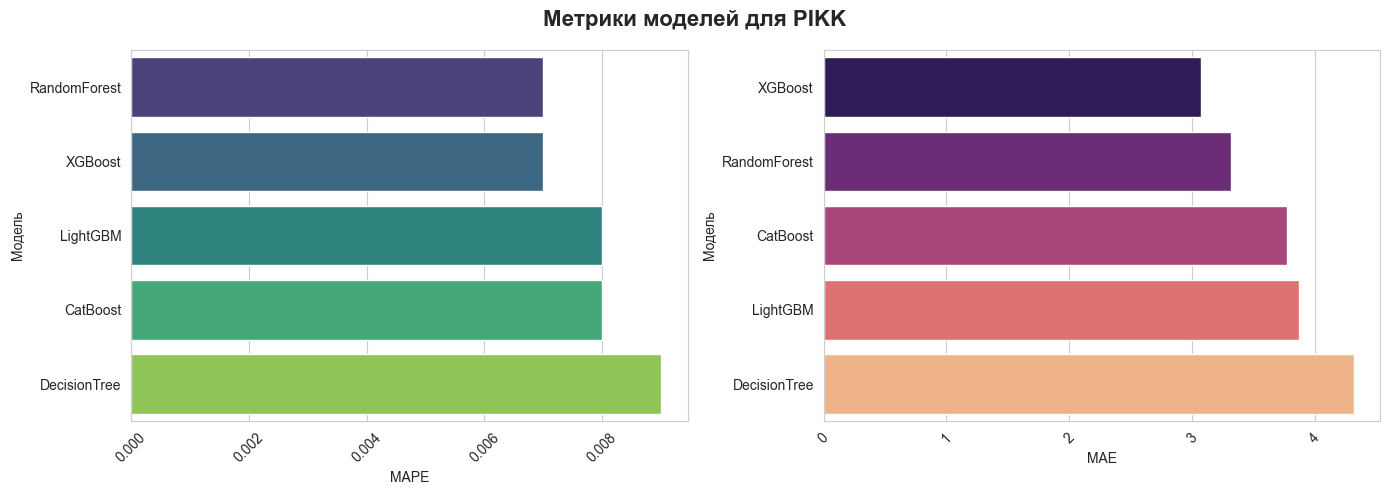

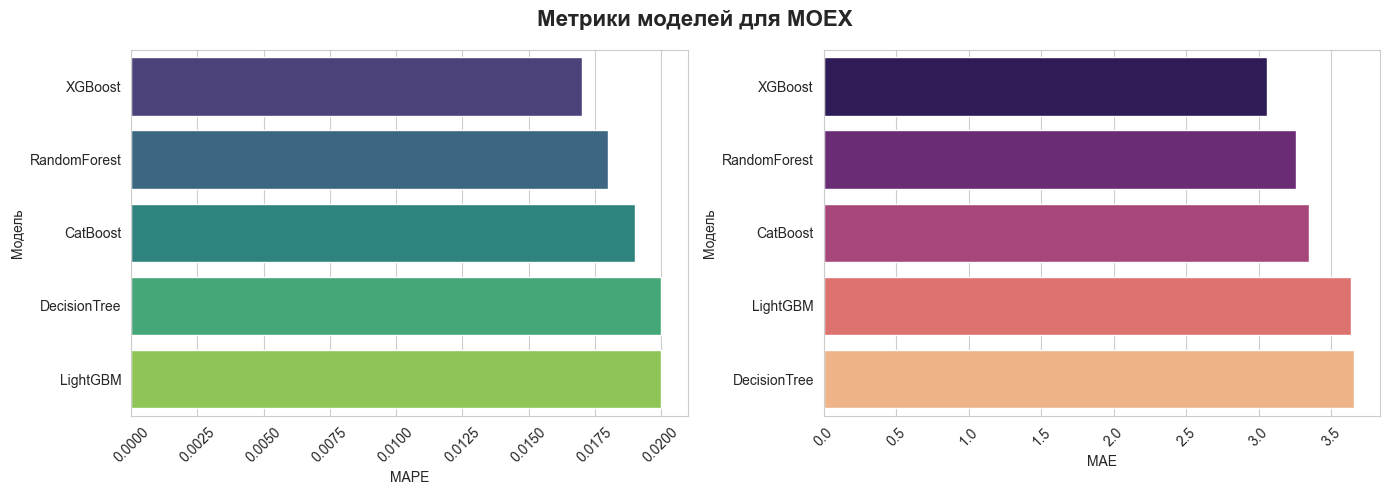

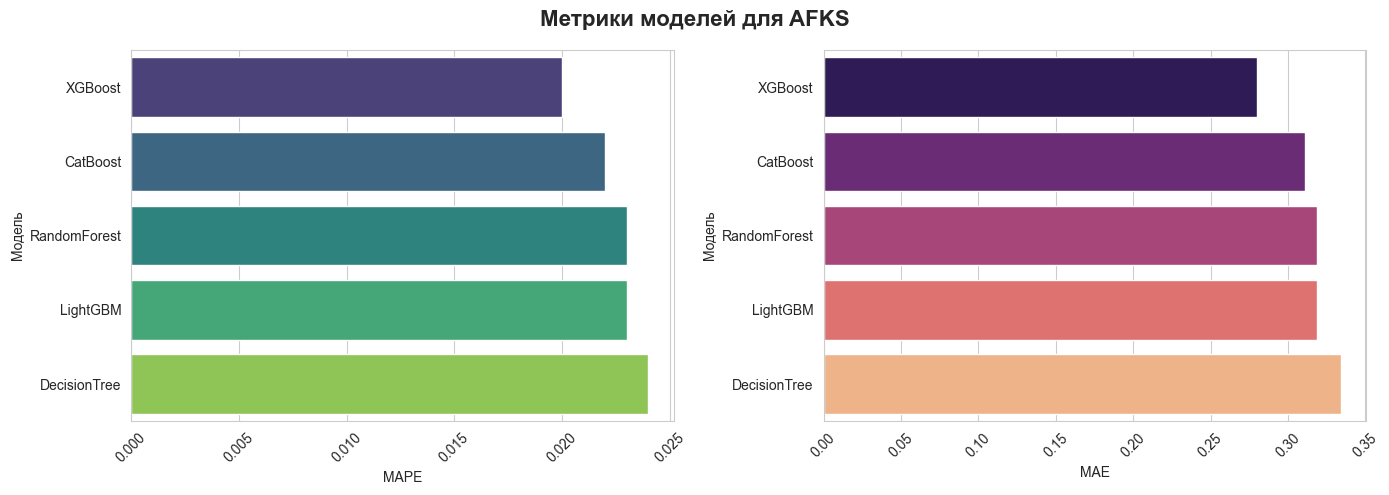

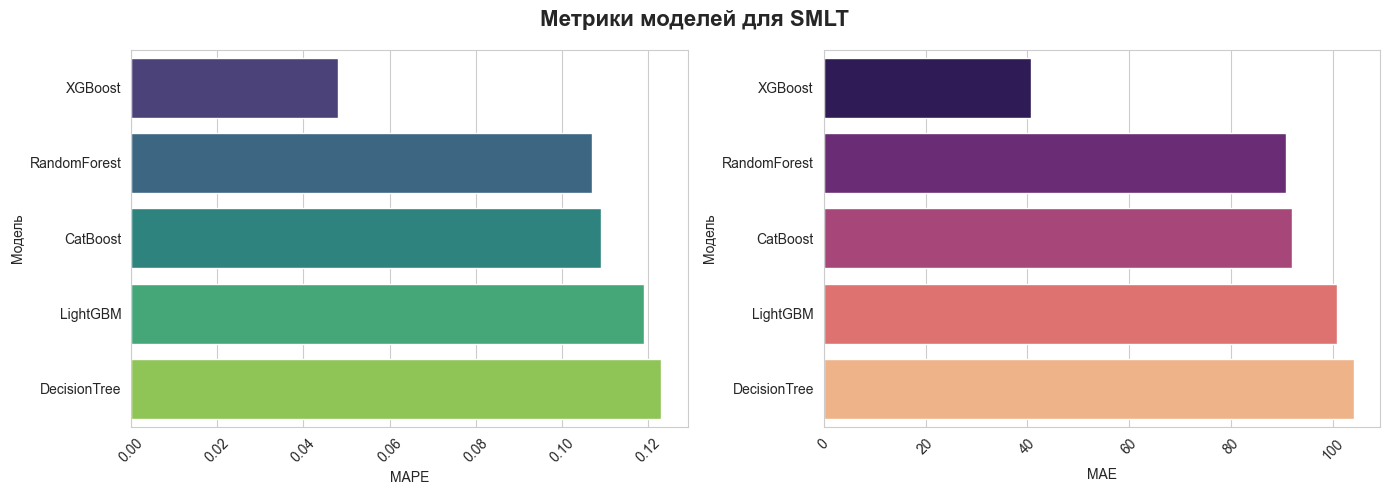

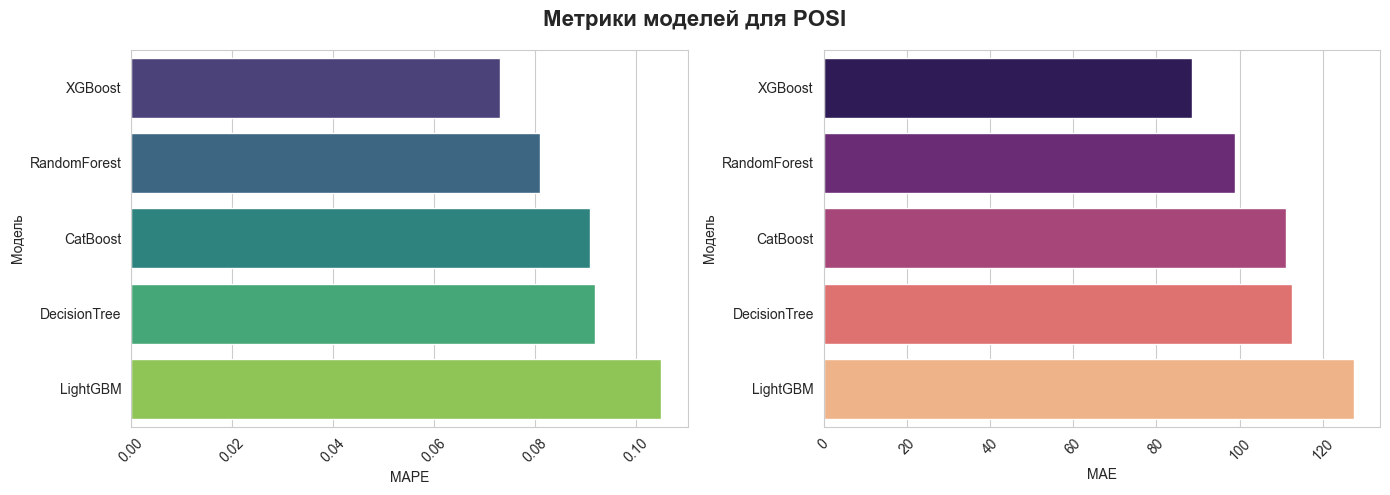

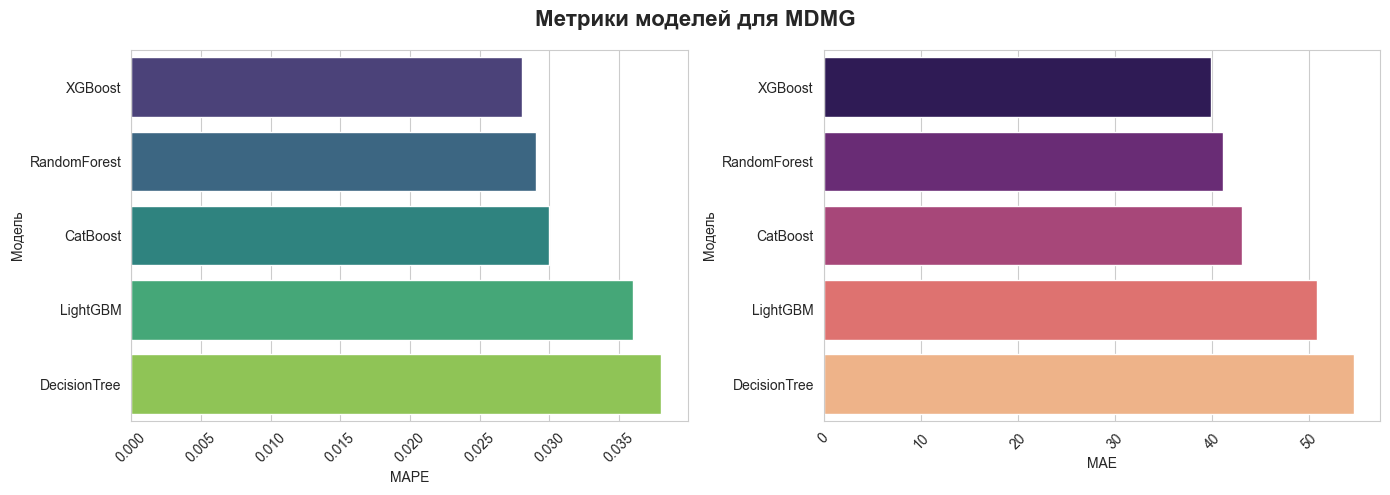

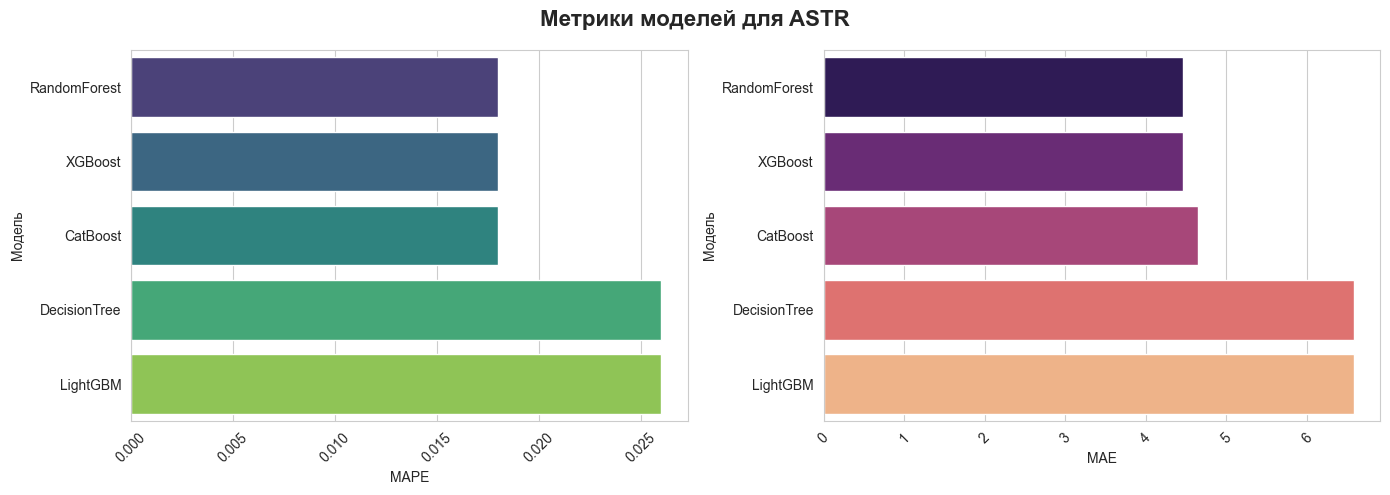

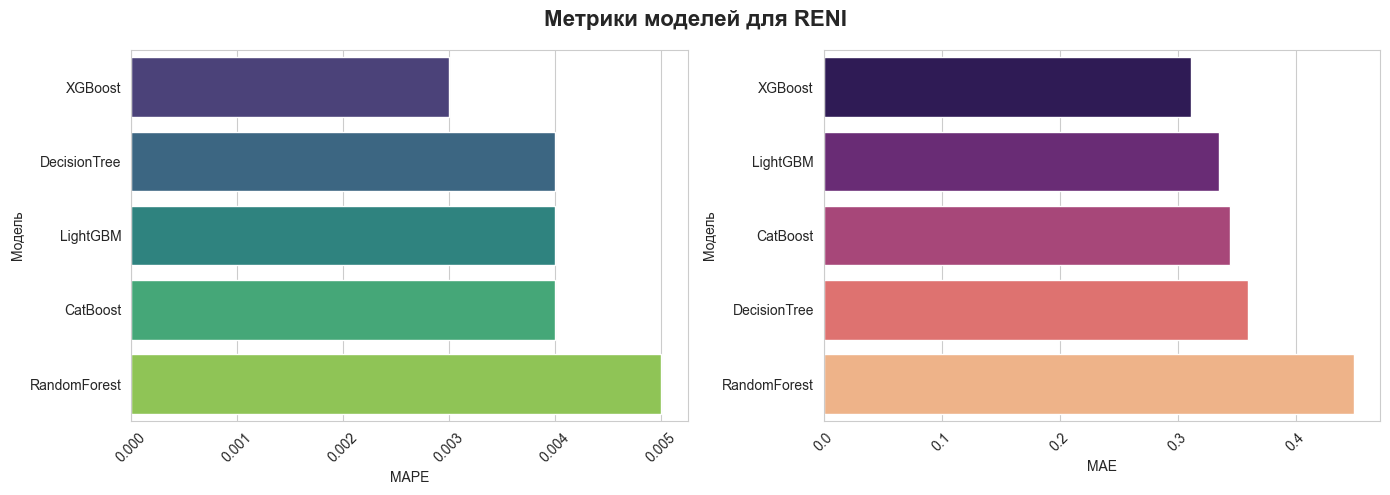

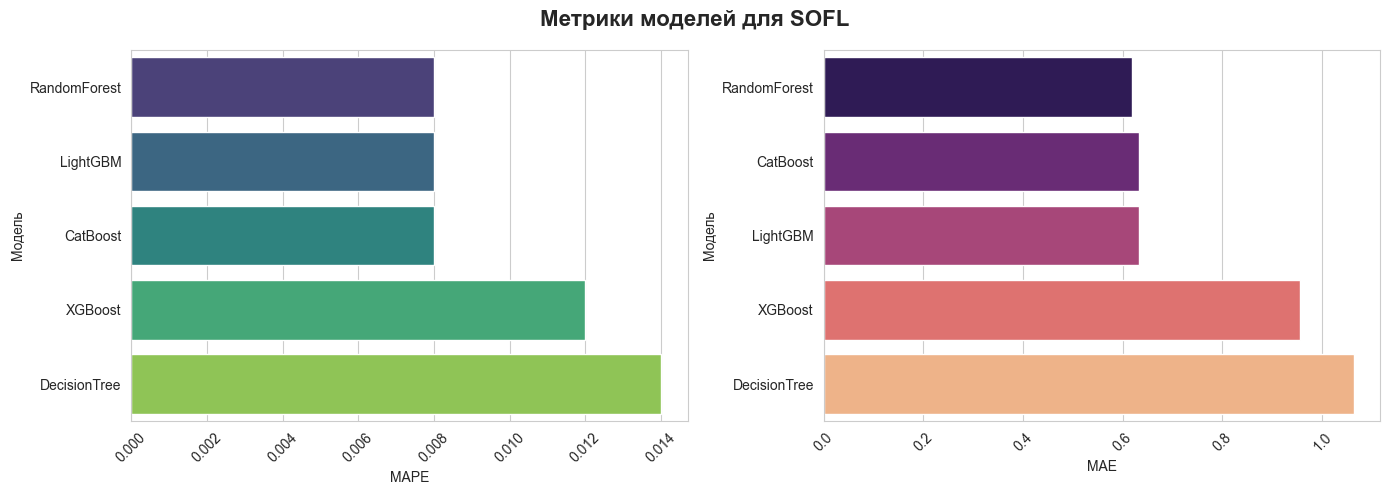

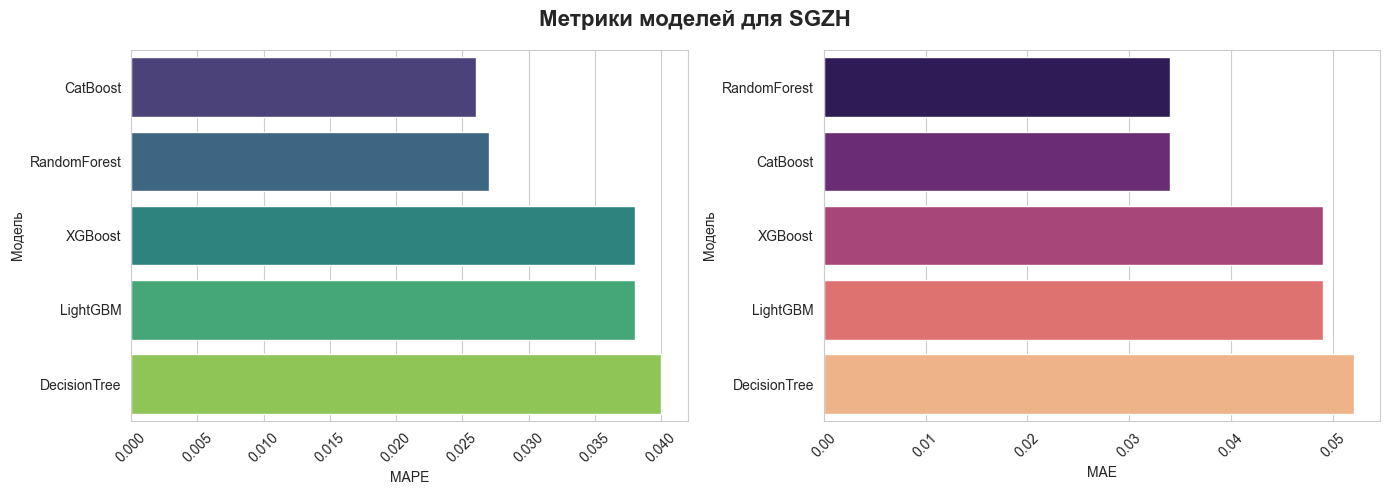

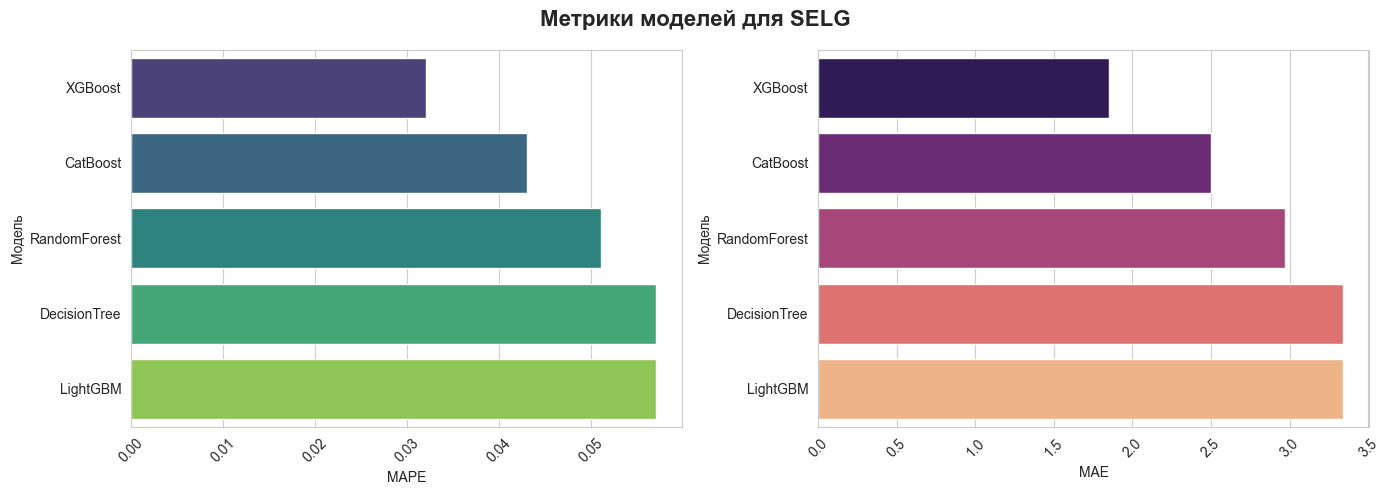

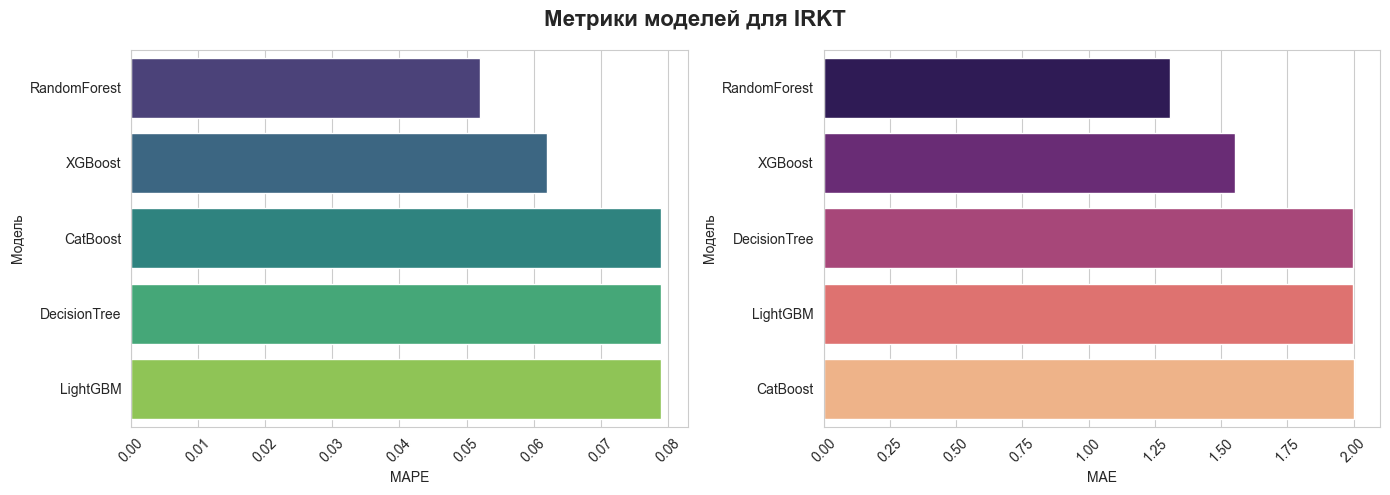

In [ ]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

for ticker in tickers:
    ticker_data = ml_models_data_2026[ml_models_data_2026['ticker'] == ticker].copy()
    plot_data = ticker_data[['model_name', 'model_value', 'mape_mean', 'mae_mean']].dropna()
    
    if plot_data.empty:
        continue
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Метрики моделей для {ticker}', fontsize=16, fontweight='bold')
    
    sns.barplot(
        data=plot_data.sort_values('mape_mean'),
        x='mape_mean', 
        y='model_name', 
        ax=axes[0],
        palette='viridis',
        hue='model_value',
        legend=False
    )
    axes[0].set_xlabel('MAPE')
    axes[0].set_ylabel('Модель')
    axes[0].tick_params(axis='x', rotation=45)
    
    sns.barplot(
        data=plot_data.sort_values('mae_mean'),
        x='mae_mean', 
        y='model_name', 
        ax=axes[1],
        palette='magma',
        hue='model_value',
        legend=False
    )
    axes[1].set_xlabel('MAE')
    axes[1].set_ylabel('Модель')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()